# Test for parameter sweeps so find the uselful plots to build for in depth analysis. Using the real `fit4function` database.

The ground truth is defined as the Pott's regression computed on the first production column in fit4function.csv. Then we simulate several experiences using our protocol by sweeping the parameter of interest and plot some useful curves to analyse the quality of the results and the predictions.

To begin, we will perform a sweep on the dilution factors, and we will evaluate the recovery in terms of pearson correlation between the MLP prediction and the production2 column, the protocol's simulation and production2. Finally an analysis in terms of top recovery by the MLP, we will plot the histogram of log enrichment predicted by the MLP on 10 millions of variants and will plot for the top 1000 variants among these 10 millions the curve x = (log enrichment for the variants). Also a top 1000 recovery for the MLP prediction versus production1 and production2.

In [1]:
import sys, os

# Locate Modelization_V2/lib by walking up from the cwd (= this notebook's dir), same idiom as
# AAV9_potts_simulated_replicate_stochasticity.ipynb: a hardcoded "../../lib" breaks every time
# the notebook moves between subfolders of Modelization_V2/notebooks/, and when it points
# nowhere `import sequence_classesV1` silently resolves to Modelization_V1's pip-installed copy
# (whose Protocol.__init__ has no `key` arg -> TypeError downstream).
_d = os.path.abspath("")
while os.path.basename(_d) != "Modelization_V2" and _d != os.path.dirname(_d):
    _d = os.path.dirname(_d)
_V2_LIB = os.path.join(_d, "lib")
assert os.path.isdir(_V2_LIB), f"Modelization_V2/lib not found walking up from {os.path.abspath('')}"
sys.path.insert(0, _V2_LIB)
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import optax
from flax import nnx
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, precision_at_k, topk_recovery
from cross_packaging_draft import ProtocolCrossPackagingBackground
from initialize_weights import (load_F_viab_aav9_potts, load_J_viab_aav9_potts,
                                 NUM_AMINO_ACIDS, NUM_POSITIONS)

import sequence_classesV1 as _scv1
assert "Modelization_V2" in _scv1.__file__, f"imported the wrong sequence_classesV1: {_scv1.__file__}"

L, A = NUM_POSITIONS, NUM_AMINO_ACIDS
print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")
print(f"sequence_classesV1: {_scv1.__file__}")

message = "AAV9 cross-packaging parameter sweeps vs fit4function, 1.0"

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]
sequence_classesV1: /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/sequence_classesV1.py


## 1. Real data -- `fit4functionaav9.csv`

`Production1`/`Production2` are the two independent replicate fold-enrichment ratios the file
already reports (not raw read counts), so they are converted to log enrichment with a plain
`log2` and rows where either replicate is not finite-and-positive are **dropped**, never
pseudocounted -- same convention as `log_enrichment_histograms.ipynb`,
`AAV9_fit4function_potts_vs_mlp.ipynb` and `discordant_variants_aav9.ipynb`.

The protocol below is simulated on **all** 74,464 rows (the simulated library is the real
library, duplicates included as-is); the both-replicates-valid mask is only applied when a
metric needs a real measurement to compare against.

In [2]:
df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")

p1 = df["Production1"].to_numpy(dtype=float)
p2 = df["Production2"].to_numpy(dtype=float)
both_valid = np.isfinite(p1) & (p1 > 0) & np.isfinite(p2) & (p2 > 0)

log2_p1 = np.full(len(df), np.nan)
log2_p2 = np.full(len(df), np.nan)
log2_p1[both_valid] = np.log2(p1[both_valid])
log2_p2[both_valid] = np.log2(p2[both_valid])

print(f"both replicates finite and > 0: {both_valid.sum():,}/{len(df):,} "
      f"({both_valid.mean():.1%}) -- the rows every real-data comparison below is restricted to")
print(f"r(Production1, Production2) over those rows = {pearson(log2_p1[both_valid], log2_p2[both_valid]):.4f}"
      "   <- the replicate ceiling")

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']
both replicates finite and > 0: 54,621/74,464 (73.4%) -- the rows every real-data comparison below is restricted to
r(Production1, Production2) over those rows = 0.8911   <- the replicate ceiling


### 1b. Sequence encoding

In [3]:
lengths = df["AA"].str.len().unique()
assert len(lengths) == 1 and int(lengths[0]) == L, f"expected all-length-{L} sequences, got {lengths}"

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["AA"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), L)                 # (N, L) raw indices
seq_oh     = np.eye(A, dtype=np.float32)[seq_matrix].reshape(len(df), -1)  # (N, L*A) one-hot
sequences  = jnp.asarray(seq_matrix)
d0         = sequences.shape[0]

print(f"seq_matrix {seq_matrix.shape}   seq_oh {seq_oh.shape}   d0 = {d0:,}")

seq_matrix (74464, 7)   seq_oh (74464, 140)   d0 = 74,464


## 2. Potts GT weights + baseline protocol configuration

`F_potts`/`J_potts` are the ridge-regression Potts ground truth built in
`AAV9_potts_regression.ipynb` -- the default GT for this project since 2026-08-27.

Baseline operating point: `mu=50`, **`T_viab=1.3`** (the base temperature for the Potts GT --
*not* the 0.8 derived against the old naive GT), `dilution factor=1e6`,`noise_viab=0.5`, `D=1e8`, `rho=1e-3`,
`N0=150*N1` (lab constraint), and `cross_packaging_rate=0.05` (the illustrative, not-yet-
calibrated value used in `AAV9_cross_packaging_and_hallucination_impact.ipynb`). Each sweep
below varies exactly ONE of these and holds the rest at this baseline.

`F_sel`/`J_sel` are zero throughout: `loop_DE()` computes the viability log enrichment
(`lambda0p` -> `lambda2p`) before `selectivity()` runs, so selectivity weights cannot affect
anything measured here.

In [4]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()
F_potts_j = jnp.asarray(F_potts, dtype=jnp.float32)
J_potts_j = jnp.asarray(J_potts, dtype=jnp.float32)
F_sel_zero = jnp.zeros_like(F_potts_j)
J_sel_zero = jnp.zeros_like(J_potts_j)

RHO_REF         = 1e-3
DILUTION_FACTOR = 1e6
N0_OVER_N1      = 150     # lab constraint: N1 stays at least 150x smaller than N0
T_SEL           = 1.0     # unused by the viability log enrichment, kept at the project default
EPS             = 1       # pseudocount on the SIMULATED read counts (lambda0p/lambda2p can be
                          # exactly 0); the real Production columns are never pseudocounted

BASELINE = dict(dilution_factor=1e6, mu=50, T_viab=1.3, noise_viab=0.5, D=1e8, cross_packaging_rate=0.05)

print(f"F_potts {F_potts.shape}   J_potts {J_potts.shape}")
print("baseline:", BASELINE)
print(f"N1 at baseline mu: {BASELINE['mu'] * d0 / RHO_REF:.3e}   "
      f"N0 = {N0_OVER_N1 * BASELINE['mu'] * d0 / RHO_REF:.3e}")

F_potts (20, 7)   J_potts (7, 7, 20, 20)
baseline: {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}
N1 at baseline mu: 3.723e+09   N0 = 5.585e+11


## 3. Fixed train/test split (shared by every sweep point)

One split of the 74,464 variants, computed once and reused at every sweep point of every sweep,
so nothing in the comparisons below is confounded by a different split:

- the **MLP trains only on the train rows** (further split 85/15 for early stopping), always on
  the *protocol's* simulated log2 enrichment as its target -- never on the real `Production`
  columns;
- **every metric in figures 1-2 is computed on the test rows only**, for the protocol readout
  and the MLP prediction alike, so the MLP is never scored on variants it was fitted on.

In [5]:
idx_train, idx_test = train_test_split(np.arange(d0), train_size=0.60, random_state=0)

_rng      = np.random.default_rng(0)
_perm     = _rng.permutation(len(idx_train))
_n_val    = int(0.15 * len(idx_train))
idx_val   = idx_train[_perm[:_n_val]]
idx_fit   = idx_train[_perm[_n_val:]]

test_valid = both_valid[idx_test]                 # test rows that also have a real measurement
idx_test_valid = idx_test[test_valid]
real_p1_test = log2_p1[idx_test_valid]
real_p2_test = log2_p2[idx_test_valid]

CEILING = dict(
    r        = pearson(real_p1_test, real_p2_test),
    prec10   = precision_at_k(real_p1_test, real_p2_test, k_frac=0.10),
    top1000  = topk_recovery(real_p1_test, real_p2_test, k=1000),
)

print(f"fit {len(idx_fit):,}   val {len(idx_val):,}   test {len(idx_test):,}  "
      f"(of which both-replicates-valid: {test_valid.sum():,})")
print("replicate ceiling on the test rows -- Production1 vs Production2:")
print(f"  Pearson r = {CEILING['r']:.4f}   top-10% recovery = {CEILING['prec10']:.4f}   "
      f"top-1000 recovery = {CEILING['top1000']:.4f}")

fit 37,977   val 6,701   test 29,786  (of which both-replicates-valid: 21,888)
replicate ceiling on the test rows -- Production1 vs Production2:
  Pearson r = 0.8902   top-10% recovery = 0.4758   top-1000 recovery = 0.3360


## 4. Machinery

### 4a. One protocol run -> simulated log2 enrichment

Cross-packaging is the only added noise mechanism (`ProtocolCrossPackagingBackground`), and
`cross_packaging_rate=0` reduces it exactly to `ProtocolV3`. `mu` (mean transfected HEK cells
per sequence) is set through `N1 = mu * d0 / rho`, and `N0 = 150 * N1`.

In [6]:
def run_protocol(dilution_factor, mu, T_viab, noise_viab, D, cross_packaging_rate, seed=0):
    """One loop_DE() round with cross-packaging only -> (d0,) simulated log2 enrichment.

    target1 = log2((lambda2p + EPS) / (lambda0p + EPS)): the post-viability NGS checkpoint over
    the input-library NGS checkpoint, i.e. the same quantity `Production1`/`Production2` measure
    on the real side, on a log2 scale so the two are directly comparable.
    """
    N1 = mu * d0 / RHO_REF
    protocol = ProtocolCrossPackagingBackground(
        multinomialNGS=True, key=jax.random.key(seed), N0=N0_OVER_N1 * N1, N1=N1,
        dilution_factor=dilution_factor, sequences=sequences, D=D,
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel_zero, J_sel=J_sel_zero,
        noise_viab=noise_viab, noise_sel=0.0, T_sel=T_SEL, T_viab=T_viab, rho=RHO_REF,
        cross_packaging_rate=cross_packaging_rate,
    )
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log2((lambda2p + EPS) / (lambda0p + EPS))


_t0 = time.time()
_check = run_protocol(**BASELINE)
print(f"baseline protocol run: {time.time() - _t0:.1f}s   "
      f"mean={_check.mean():+.2f}  std={_check.std():.2f}  "
      f"r(vs real Production1, test rows) = {pearson(_check[idx_test_valid], real_p1_test):+.4f}")

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   2%|▎         | 1/40 [00:01<00:40,  1.03s/it]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  88%|████████▊ | 35/40 [00:00<00:00, 345.41it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

baseline protocol run: 26.1s   mean=-6.14  std=5.30  r(vs real Production1, test rows) = +0.7332


### 4b. `ProfileMLP` -- this project's standard shallow architecture

Verbatim `ShallowProfileMLP` + training loop from `AAV9_fit4function_potts_vs_mlp.ipynb`. At every sweep point a **fresh** model is trained from scratch on that point's protocol log2 enrichment, so nothing leaks between sweep values.

In [7]:
class ShallowProfileMLP(nnx.Module):
    """This project's standard ProfileMLP (Linear + BatchNorm + Dropout + gelu, twice, then a
    scalar linear head) over the 140-d one-hot input."""

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = nnx.gelu(self.batchnorm1(x))
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = nnx.gelu(self.batchnorm2(x))
        x = self.dropout2(x, rngs=rngs) if train else x
        return self.linear3(x)[:, 0]


@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        return jnp.mean((model(x, train=True, rngs=rngs) - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    return jnp.mean((model(x, train=False) - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_mlp(y_target, epochs=200, batch_size=256, peak_lr=1e-3, final_lr=1e-5,
              patience=20, seed=0, verbose=False, fit_idx=None, val_idx=None, x_oh=None):
    """Fresh ShallowProfileMLP trained on `y_target` over `fit_idx`/`val_idx` (default the
    module-level idx_fit/idx_val, i.e. the protocol's simulated log2 enrichment). Pass a
    filtered subset -- e.g. rows where a real replicate is valid -- to train on something other
    than the sweep's simulated target (section 4f). Returns (model, best_val_mse, best_epoch)."""
    fit_idx = idx_fit if fit_idx is None else fit_idx
    val_idx = idx_val if val_idx is None else val_idx
    _xoh   = seq_oh if x_oh is None else x_oh
    rngs  = nnx.Rngs(seed)
    model = ShallowProfileMLP(input_dim=L * A, rngs=rngs)

    X_fit, y_fit = jnp.asarray(_xoh[fit_idx]), jnp.asarray(y_target[fit_idx])
    X_val, y_val = jnp.asarray(_xoh[val_idx]), jnp.asarray(y_target[val_idx])

    n_fit           = X_fit.shape[0]
    steps_per_epoch = max(n_fit // batch_size, 1)
    total_steps     = steps_per_epoch * epochs
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr, warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9), end_value=final_lr)
    optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=schedule), wrt=nnx.Param)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, best_epoch, bad_epochs = float("inf"), None, 0, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm   = jax.random.permutation(perm_key, n_fit)
        Xs, ys = X_fit[perm], y_fit[perm]
        for start in range(0, n_fit - n_fit % batch_size, batch_size):
            train_step(model, optimizer, Xs[start:start + batch_size], ys[start:start + batch_size], rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs, best_epoch = val_loss, 0, epoch
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        nnx.update(model, best_state)
    if verbose:
        print(f"  MLP: best val MSE {best_val:.4f} at epoch {best_epoch}")
    return model, best_val, best_epoch


n_params = sum(p.size for p in jax.tree.leaves(
    nnx.state(ShallowProfileMLP(input_dim=L * A, rngs=nnx.Rngs(0)), nnx.Param)))
print(f"ShallowProfileMLP: {n_params:,} params")

ShallowProfileMLP: 26,753 params


### 4c. Sequence-space sample -- 10,000,000 variants, not the full 20^7

Every question below ("what does the MLP think the best variants are, and are they actually
good?") is asked on **one fixed random sample of 10,000,000 variants** drawn uniformly from the
20^7 = 1.28e9 space, instead of scanning the whole space.

Why this is the better object to work with here:

- **The two rankings live on the same finite population.** The MLP's top-1000 and the GT's
  top-1000 are both subsets of the same 10M variants, so their overlap at any `k` is an exact
  set intersection -- an `argsort`, nothing else. The full-space version could not do that
  (holding a 1.28e9-long ranking is not possible), which is why it needed a binned joint
  histogram *and* a Potts surrogate to make the two rankings comparable at all. Both of those
  approximations are gone.
- **The MLP's log2 enrichment never has to be converted into a score.** It is histogrammed on
  its own axis, and its top-1000 picks are then looked up on the GT axis. Two axes, two
  quantities, no rescaling and no surrogate fit.
- It is ~130x cheaper per sweep point, so a sweep runs in minutes rather than half an hour.

The cost is the tail depth: the best of 10M is around the 128th-best of the full space in
expectation, so "the global optimum" is out of reach by construction. That is fine -- the
question here is *comparative* (which dilution factor gives a model that ranks variants best),
and every sweep point is scored on the identical sample.

`TOP_K = 1000` throughout.


In [8]:
SCAN_SIZE = 10_000_000       # variants sampled from the full space, fixed for the whole notebook
TOP_K     = 1000             # "top-1000" everywhere below
SCAN_CHUNK = 1_000_000       # variants per GPU chunk (one-hot chunk = 560 MB at L*A = 140)
TOTAL     = A ** L           # 1,280,000,000 -- the space the sample is drawn FROM


@jax.jit
def _decode(idx):
    """Linear index -> (n, L) amino-acid index sequence (base-A digits, most significant first)."""
    tmp, digits = idx, []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    return jnp.stack(digits[::-1], axis=1).astype(jnp.int32)


@jax.jit
def gt_score_of_idx(idx):
    """Potts GT score of each linear index -- same formula as Protocol.compute_score()."""
    seq    = _decode(idx)
    scores = jnp.sum(F_potts_j[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J_potts_j[i, j, seq[:, i], seq[:, j]]
    return scores


@nnx.jit
def _predict_idx_chunk(model, idx):
    """The MLP's predicted log2 enrichment for a chunk of linear indices."""
    seq = _decode(idx)
    oh  = jax.nn.one_hot(seq, A, dtype=jnp.float32).reshape(seq.shape[0], L * A)
    return model(oh, train=False)


def _chunked(fn, idx, desc, chunk=SCAN_CHUNK):
    """Applies `fn` to `idx` in chunks and concatenates on the host (float32, (n,))."""
    out = np.empty(len(idx), dtype=np.float32)
    for s in tqdm(range(0, len(idx), chunk), desc=desc, leave=False):
        out[s:s + chunk] = np.asarray(fn(jnp.asarray(idx[s:s + chunk])))
    return out


def mlp_scan(model):
    """The MLP's predicted log2 enrichment for the whole 10M sample."""
    return _chunked(lambda i: _predict_idx_chunk(model, i), SCAN_IDX, f"MLP scan ({len(SCAN_IDX):,})")


# ---- the sample itself -------------------------------------------------------------------
# Drawn with replacement then deduplicated (~39k collisions expected at 10M out of 1.28e9):
# duplicates would let one variant occupy two slots of a top-k set and quietly inflate every
# recovery number. np.unique also sorts, which costs nothing here and makes the sample
# reproducible independently of the draw order.
_t0 = time.time()
SCAN_IDX = np.unique(np.random.default_rng(0).integers(0, TOTAL, size=SCAN_SIZE, dtype=np.int64))
SCAN_GT  = _chunked(gt_score_of_idx, SCAN_IDX, "GT score of the sample")

# GT ranking of the sample, computed once: GT_RANK[i] = position of sample variant i in the GT
# ordering (0 = best). Every top-k recovery below is read off this array.
GT_ORDER = np.argsort(-SCAN_GT)
GT_RANK  = np.empty(len(SCAN_IDX), dtype=np.int64)
GT_RANK[GT_ORDER] = np.arange(len(SCAN_IDX))
GT_TOP_GT = SCAN_GT[GT_ORDER[:TOP_K]]        # the best the MLP could possibly pick, in this sample

# Where the REAL library sits in the same landscape (same base-A index as _decode, position 0 =
# most significant digit), so the 74,464 designed variants can be scored by the same function.
REAL_LIB_IDX = (seq_matrix * (A ** np.arange(L - 1, -1, -1))).sum(axis=1)
REAL_LIB_GT  = np.asarray(gt_score_of_idx(jnp.asarray(REAL_LIB_IDX)))

# k grid for the recovery curve: log-spaced up to a tenth of the sample.
K_GRID = np.unique(np.round(np.logspace(1, np.log10(SCAN_SIZE // 10), 24)).astype(np.int64))
GT_RECOVERY_DEPTHS = [1_000, 10_000, 100_000, 1_000_000]


def topk_overlap_curve(pred, ks=K_GRID):
    """Exact |top-k by MLP  &  top-k by GT| / k, at every k in `ks`, over the sample.

    `GT_RANK[order][:k] < k` is that intersection: it counts how many of the MLP's k best are
    also in the GT's k best. No binning, no interpolation -- both rankings are over the same
    finite population, so this is the true set overlap."""
    order = np.argsort(-pred)
    gr    = GT_RANK[order]
    return np.array([np.count_nonzero(gr[:k] < k) / k for k in ks])


def mlp_top_k(pred, k=TOP_K):
    """Positions (into the sample) of the k highest predicted log2 enrichments, best first."""
    part = np.argpartition(-pred, k)[:k]
    return part[np.argsort(-pred[part])]


print(f"sample: {len(SCAN_IDX):,} unique variants of {TOTAL:,} "
      f"({len(SCAN_IDX) / TOTAL:.2e} of the space), scored in {time.time() - _t0:.1f}s")
print(f"GT score over the sample:  min={SCAN_GT.min():+.2f}  median={np.median(SCAN_GT):+.2f}  "
      f"max={SCAN_GT.max():+.2f}   top-{TOP_K} median={np.median(GT_TOP_GT):+.2f}")
print(f"GT score, real library:    min={REAL_LIB_GT.min():+.2f}  "
      f"median={np.median(REAL_LIB_GT):+.2f}  max={REAL_LIB_GT.max():+.2f}  "
      f"({len(REAL_LIB_GT):,} variants)")
print(f"variants of the sample beating the best real-library variant: "
      f"{int((SCAN_GT > REAL_LIB_GT.max()).sum()):,}")

GT score of the sample:   0%|          | 0/10 [00:00<?, ?it/s]

GT score of the sample:  10%|█         | 1/10 [00:00<00:02,  3.24it/s]

GT score of the sample: 100%|██████████| 10/10 [00:00<00:00, 17.73it/s]

sample: 9,961,098 unique variants of 1,280,000,000 (7.78e-03 of the space), scored in 8.3s
GT score over the sample:  min=-27.54  median=-0.15  max=+15.83   top-1000 median=+9.49
GT score, real library:    min=-17.85  median=-0.25  max=+9.52  (74,464 variants)
variants of the sample beating the best real-library variant: 460


### 4d. One sweep point

Runs the protocol at that parameter value, trains a **fresh** MLP on its simulated log2
enrichment (never on the real `Production` columns), then measures two different things:

1. **against the real experiment** -- Pearson r, top-10% and top-1000 recovery of the protocol
   readout and of the MLP prediction against `Production1` and `Production2`, on the held-out
   test rows only;
2. **against the ground truth, over the 10M sample** -- the MLP's predicted log2 enrichment for
   all 10M, its own top-1000, the GT score of those same 1000, and the exact top-k overlap
   between the MLP's ranking and the GT's.

Only summaries of the 10M-long prediction are kept (histogram + top-1000 + recovery curve), so
a full sweep holds a few MB rather than a few hundred.


In [9]:
def evaluate_point(value, param, seed=0, verbose=True):
    """One (parameter -> value) sweep point."""
    cfg = dict(BASELINE)
    cfg[param] = value
    t_start = time.time()

    target = run_protocol(**cfg, seed=seed)
    model, val_mse, best_epoch = train_mlp(target, seed=seed)
    pred = np.asarray(predict_log_enrichment(model, jnp.asarray(seq_oh)))

    proto_test, mlp_test = target[idx_test_valid], pred[idx_test_valid]
    out = dict(param=param, value=value, config=cfg, val_mse=val_mse, best_epoch=best_epoch,
               target=target, pred=pred, proto_test=proto_test, mlp_test=mlp_test)

    # --- 1. recovery of the REAL experiment, held-out test rows --------------------------
    for name, v in (("proto", proto_test), ("mlp", mlp_test)):
        for rep, real in (("p1", real_p1_test), ("p2", real_p2_test)):
            out[f"r_{name}_{rep}"]      = pearson(v, real)
            out[f"prec10_{name}_{rep}"] = precision_at_k(real, v, k_frac=0.10)
            out[f"top1000_{name}_{rep}"] = topk_recovery(v, real, k=TOP_K)
        for metric in ("r", "prec10", "top1000"):
            out[f"{metric}_{name}"] = 0.5 * (out[f"{metric}_{name}_p1"] + out[f"{metric}_{name}_p2"])

    # --- 2. the MLP over the 10M sample ---------------------------------------------------
    scan_pred = mlp_scan(model)
    top_pos   = mlp_top_k(scan_pred)                 # positions into the sample, best first
    top_pred  = scan_pred[top_pos]                   # their predicted log2 enrichment
    top_gt    = SCAN_GT[top_pos]                     # where those same 1000 really are
    top_rank  = GT_RANK[top_pos]                     # their rank in the GT ordering of the sample

    out.update(
        top_idx=SCAN_IDX[top_pos], top_pred=top_pred, top_gt=top_gt, top_gt_rank=top_rank,
        gt_median_of_mlp_top=float(np.median(top_gt)),
        gt_max_of_mlp_top=float(top_gt.max()),
        r_mlp_vs_gt_sample=pearson(scan_pred, SCAN_GT),
        recovery_k=K_GRID, recovery_curve=topk_overlap_curve(scan_pred),
        n_top_beating_real_library=int((top_gt > REAL_LIB_GT.max()).sum()),
    )
    # of the MLP's 1000 picks, how many are in the GT's true top-K of the same sample?
    for k in GT_RECOVERY_DEPTHS:
        out[f"gt_recovery_top{k}"] = float(np.mean(top_rank < k))
    out["gt_top1000_overlap"] = out["gt_recovery_top1000"]   # = |MLP top-1000 & GT top-1000|/1000

    out["elapsed"] = time.time() - t_start
    if verbose:
        print(f"  {param}={value:<10.4g} r_proto={out['r_proto']:+.3f} r_mlp={out['r_mlp']:+.3f} "
              f"top{TOP_K}_mlp={out['top1000_mlp']:.3f} | sample: r(MLP,GT)="
              f"{out['r_mlp_vs_gt_sample']:+.3f}  GT median of its top-{TOP_K}="
              f"{out['gt_median_of_mlp_top']:+.2f} (GT's own: {np.median(GT_TOP_GT):+.2f})  "
              f"top-{TOP_K} overlap with GT={out['gt_top1000_overlap']:.1%}  "
              f"[{out['elapsed']:.0f}s]")
    return out


def run_sweep(param, values, seed=0):
    print(f"=== sweep: {param}  (everything else at baseline {BASELINE}) ===")
    results = [evaluate_point(v, param, seed=seed) for v in values]
    print(f"=== done, {sum(r['elapsed'] for r in results) / 60:.1f} min ===")
    return results


def summarize(results):
    return pd.DataFrame([{
        "param": r["param"], "value": r["value"],
        "r_proto": r["r_proto"], "r_mlp": r["r_mlp"],
        "r_proto_p2": r["r_proto_p2"], "r_mlp_p2": r["r_mlp_p2"],
        "prec10_proto": r["prec10_proto"], "prec10_mlp": r["prec10_mlp"],
        "top1000_proto": r["top1000_proto"], "top1000_mlp": r["top1000_mlp"],
        "r_mlp_vs_gt_sample": r["r_mlp_vs_gt_sample"],
        "gt_median_mlp_top1000": r["gt_median_of_mlp_top"],
        **{f"gt_recovery_top{k}": r[f"gt_recovery_top{k}"] for k in GT_RECOVERY_DEPTHS},
        "n_top_beating_real_library": r["n_top_beating_real_library"],
        "val_mse": r["val_mse"], "elapsed_s": r["elapsed"],
    } for r in results]).round(4)

### 4e. The three figures

1. `plot_distributions` -- real Production1 vs protocol (top row) and real Production1 vs MLP
   (bottom row), median-aligned, one panel per sweep value.
2. `plot_recovery` -- Pearson r, top-10% and top-1000 recovery of the real experiment, versus
   the swept parameter, for the protocol readout and for the MLP (mean of both replicates), with
   the replicate ceiling drawn in, and -- on the top-1000 panel -- the top-1000 recovery of the
   real-data-trained baseline MLP from section 4f.
3. `plot_topk_recovery` -- exact overlap between the MLP's top-k and the GT's top-k over the
   sample, as a function of k, one curve per sweep value.


In [10]:
REAL_COLOR, PROTO_COLOR, MLP_COLOR = "tab:orange", "teal", "tab:red"


def _sweep_colors(results, cmap="viridis"):
    return plt.get_cmap(cmap)(np.linspace(0.1, 0.9, len(results)))


def _label(res):
    return f"{res['param']} = {res['value']:.4g}"


def plot_distributions(results, param, bins=70):
    """Figure 1 -- real aav9 Production1 vs protocol (top row) and vs MLP (bottom row), one
    panel per sweep value, instead of the three overlaid on one axis. Each curve is
    independently shifted by (median_real - median_curve) so the SHAPES can be compared: the
    real Production column is a normalized ratio while the simulated/predicted target is a raw
    read ratio, so a constant log2 offset is expected and carries no information (a shift
    changes neither Pearson r nor any top-k recovery)."""
    n = len(results)
    fig, axes = plt.subplots(2, n, figsize=(3.6 * n, 7.2), sharex="row")
    axes = np.atleast_2d(axes).reshape(2, n)

    rows = [("proto_test", "protocol", PROTO_COLOR), ("mlp_test", "MLP prediction", MLP_COLOR)]
    for col, res in enumerate(results):
        for row, (key, label, color) in enumerate(rows):
            v = res[key]
            shift = float(np.median(real_p1_test) - np.median(v))
            v_shifted = v + shift
            ax  = axes[row, col]
            rng = (min(real_p1_test.min(), v_shifted.min()), max(real_p1_test.max(), v_shifted.max()))
            b   = np.linspace(*rng, bins)
            ax.hist(real_p1_test, bins=b, alpha=0.5, density=True, color=REAL_COLOR, label="real Production1")
            ax.hist(v_shifted, bins=b, alpha=0.5, density=True, color=color,
                    label=f"{label} (shifted {shift:+.1f})")
            ax.set_xlabel("log2 enrichment")
            if col == 0:
                ax.set_ylabel(f"density -- real vs {label}")
            ax.set_title(_label(res), fontsize=10)
            ax.grid(True, ls="--", alpha=0.3)
            ax.legend(fontsize=8)
    fig.suptitle(f"Log2 enrichment -- real vs protocol (top) and real vs MLP (bottom), sweeping {param}\n"
                 f"(held-out test rows, n={len(real_p1_test):,}, each curve median-aligned to real)")
    fig.tight_layout()
    plt.show()


def plot_recovery(results, param, logx=False):
    """Figure 2 -- recovery of the REAL experiment as a function of the swept parameter.
    Solid = mean over the two replicates, black dashed = the Production1-vs-Production2
    replicate ceiling. A third reference line (section 4f) on EVERY panel shows the matching
    metric for a ShallowProfileMLP trained directly on real Production1 and evaluated against
    Production2 -- independent of the swept parameter, since it never goes through the
    protocol simulation. `TOP_K` sets what "top-k" means throughout, currently 1000."""
    x = np.array([r["value"] for r in results], dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    panels = [("r", "Pearson r", CEILING["r"]),
              ("prec10", "top-10% recovery", CEILING["prec10"]),
              ("top1000", f"top-{TOP_K} recovery", CEILING["top1000"])]

    for ax, (metric, title, ceiling) in zip(axes, panels):
        for name, color, label in [("proto", PROTO_COLOR, "protocol readout"),
                                   ("mlp", MLP_COLOR, "MLP prediction")]:
            ax.plot(x, [r[f"{metric}_{name}"] for r in results], "o-", color=color, lw=2,
                    label=f"{label} (mean of P1/P2)")
        ax.axhline(ceiling, color="black", ls="--", alpha=0.7,
                   label=f"replicate ceiling = {ceiling:.3f}")
        ax.axhline(REAL_MLP_BASELINE[metric], color="tab:purple", ls="--", alpha=0.8,
                   label=f"MLP trained on real Production1 = {REAL_MLP_BASELINE[metric]:.3f}")
        ax.set_xlabel(param)
        ax.set_ylabel(title)
        ax.set_title(f"{title} vs the real experiment")
        if logx:
            ax.set_xscale("log")
        ax.legend(fontsize=7.5, loc="best")
        ax.grid(True, ls="--", alpha=0.3)
    fig.suptitle(f"Recovery of the real fit4function experiment vs {param}   "
                 f"(held-out test rows, n={len(real_p1_test):,})")
    fig.tight_layout()
    plt.show()


def plot_topk_recovery(results, param, logx=False):
    """Figure 3 -- exact |top-k by MLP & top-k by GT| / k over the sample, versus k (left), and
    read at the fixed depths of interest versus the swept parameter (right)."""
    colors = _sweep_colors(results)
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.9))

    ax = axes[0]
    for res, c in zip(results, colors):
        ax.plot(res["recovery_k"], res["recovery_curve"], "o-", ms=3, color=c, lw=1.6,
                label=_label(res))
    ax.plot(K_GRID, K_GRID / len(SCAN_IDX), ":", color="black", alpha=0.7,
            label="random picking")
    ax.set_xscale("log")
    ax.set_xlabel("k")
    ax.set_ylabel("top-k overlap with the GT")
    ax.set_title(f"MLP ranking vs GT ranking over the {len(SCAN_IDX):,}-variant sample", fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, ls="--", alpha=0.3)

    ax = axes[1]
    x = np.array([r["value"] for r in results], dtype=float)
    for k, marker in zip(GT_RECOVERY_DEPTHS, "os^v"):
        ax.plot(x, [r[f"gt_recovery_top{k}"] for r in results], marker + "-", lw=2,
                label=f"MLP's top-{TOP_K} inside the GT's top-{k:,}")
    ax.set_xlabel(param)
    ax.set_ylabel("fraction of the MLP's picks")
    ax.set_title(f"Are the MLP's {TOP_K} picks actually good?", fontsize=10)
    if logx:
        ax.set_xscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, ls="--", alpha=0.3)

    fig.suptitle(f"Top-k recovery of the ground truth vs {param}")
    fig.tight_layout()
    plt.show()


def show_sweep(results, param, logx=False):
    plot_distributions(results, param)
    plot_recovery(results, param, logx=logx)
    plot_topk_recovery(results, param, logx=logx)

### 4f. Baseline -- MLP trained directly on the real experiment

A point of comparison independent of the protocol simulation and of the swept parameter: a
fresh `ShallowProfileMLP` trained directly on real `log2(Production1)` (fit/val rows restricted
to where Production1 is valid), then evaluated -- like every other model in this notebook -- on
the held-out test rows against `Production2`. This is the ceiling the *simulation-trained* MLPs
in the sweep are chasing: how much of the replicate gap a denoising model can close when it
learns from the real experiment instead of the protocol's simulated approximation of it.

Computed **once**, not per sweep point (`dilution_factor` never enters this model), and used as
a flat reference line in figure 2 (`REAL_MLP_BASELINE["top1000"]`).


In [11]:
idx_fit_real = idx_fit[both_valid[idx_fit]]
idx_val_real = idx_val[both_valid[idx_val]]

_t0 = time.time()
real_mlp, real_val_mse, real_best_epoch = train_mlp(
    log2_p1, seed=0, fit_idx=idx_fit_real, val_idx=idx_val_real)
real_mlp_pred_test = np.asarray(
    predict_log_enrichment(real_mlp, jnp.asarray(seq_oh[idx_test_valid])))

REAL_MLP_BASELINE = dict(
    r        = pearson(real_mlp_pred_test, real_p2_test),
    prec10   = precision_at_k(real_p2_test, real_mlp_pred_test, k_frac=0.10),
    top1000  = topk_recovery(real_mlp_pred_test, real_p2_test, k=TOP_K),
)

print(f"MLP trained on real Production1 ({len(idx_fit_real):,} fit / {len(idx_val_real):,} val "
      f"rows, val MSE {real_val_mse:.4f} @ epoch {real_best_epoch}), evaluated vs Production2 "
      f"on the held-out test rows ({time.time() - _t0:.0f}s):")
print(f"  Pearson r = {REAL_MLP_BASELINE['r']:.4f}   top-10% recovery = {REAL_MLP_BASELINE['prec10']:.4f}   "
      f"top-{TOP_K} recovery = {REAL_MLP_BASELINE['top1000']:.4f}")

MLP trained on real Production1 (27,826 fit / 4,907 val rows, val MSE 3.4872 @ epoch 27), evaluated vs Production2 on the held-out test rows (18s):
  Pearson r = 0.8715   top-10% recovery = 0.4776   top-1000 recovery = 0.3050


## 5. Sweep -- `dilution_factor`

The pipetting step of every NGS checkpoint: each molecule of the measured pool lands in the
sequenced aliquot with probability `1 / dilution_factor` (a Binomial draw, `Lambda.sample_sequences`).
It is the one knob that sets **how many molecules of each variant physically reach the
sequencer**, before any read is drawn -- so it caps the information the readout can carry, no
matter how deep `D` is.

At the baseline `N0 = 150 * N1 = 5.6e11` over 74,464 variants, the input library holds ~7.5e6
molecules per variant, so the grid below spans about 75,000 molecules per variant pipetted
(`1e2`) down to well under one (`1e7`), i.e. from "sampling adds nothing" to "most variants miss
the aliquot entirely".


In [12]:
GRID_DILUTION = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7]
res_dilution  = run_sweep("dilution_factor", GRID_DILUTION)

=== sweep: dilution_factor  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 44.85it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 45.55it/s]

  dilution_factor=1e+07      r_proto=+0.351 r_mlp=+0.568 top1000_mlp=0.173 | sample: r(MLP,GT)=+0.641  GT median of its top-1000=+7.99 (GT's own: +9.49)  top-1000 overlap with GT=7.9%  [34s]
=== done, 5.7 min ===


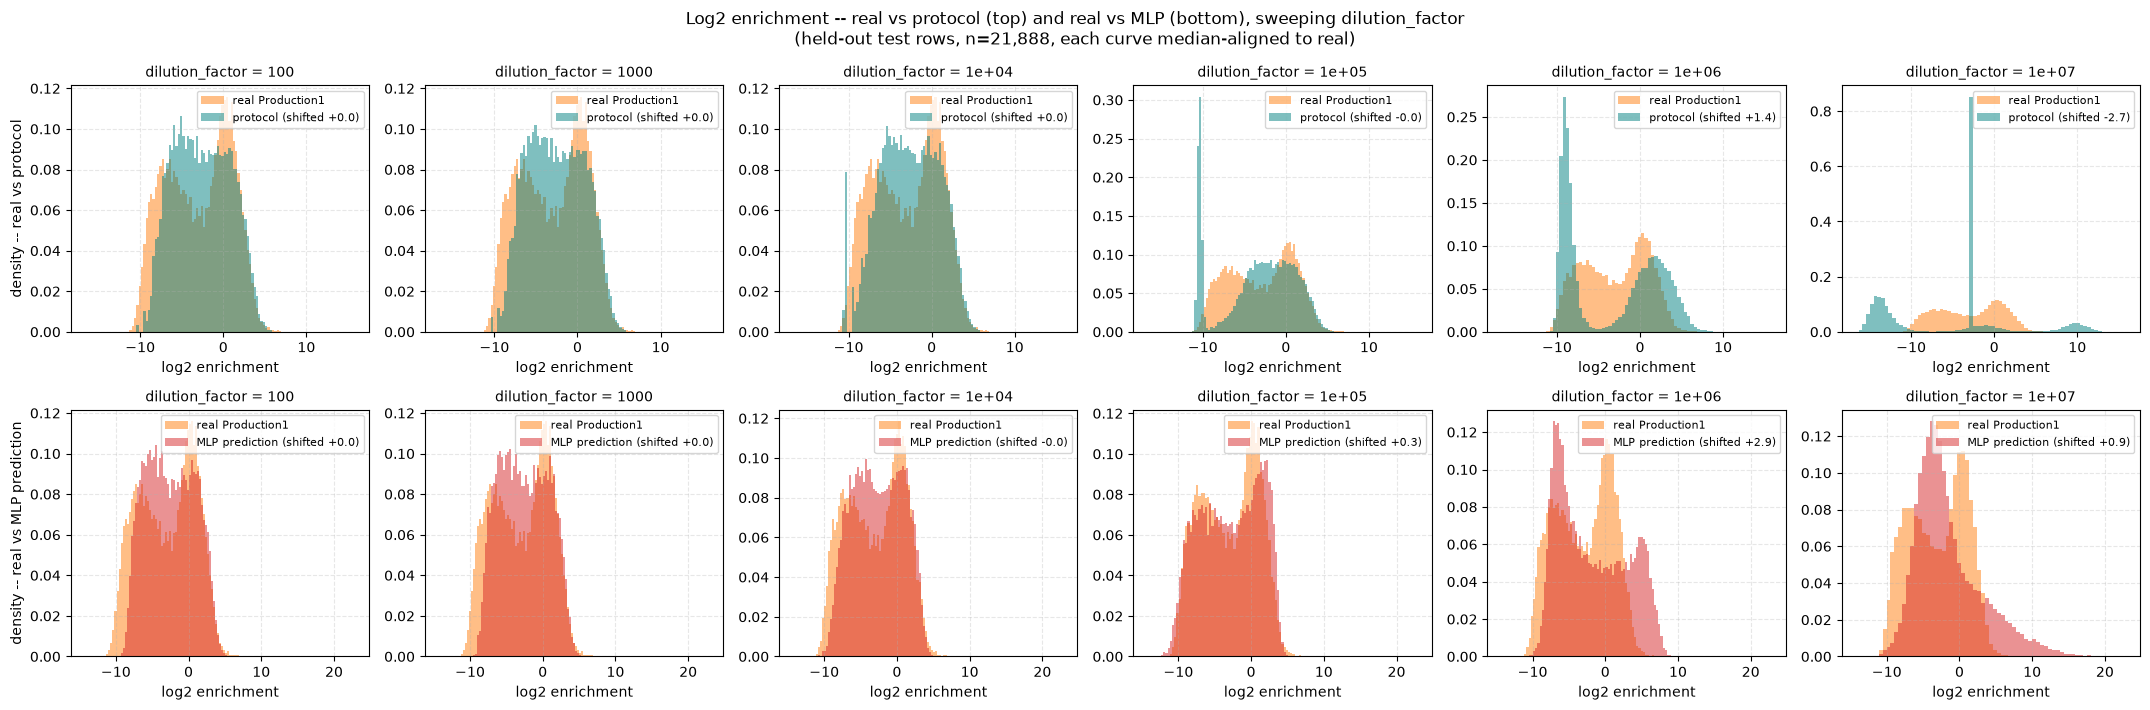

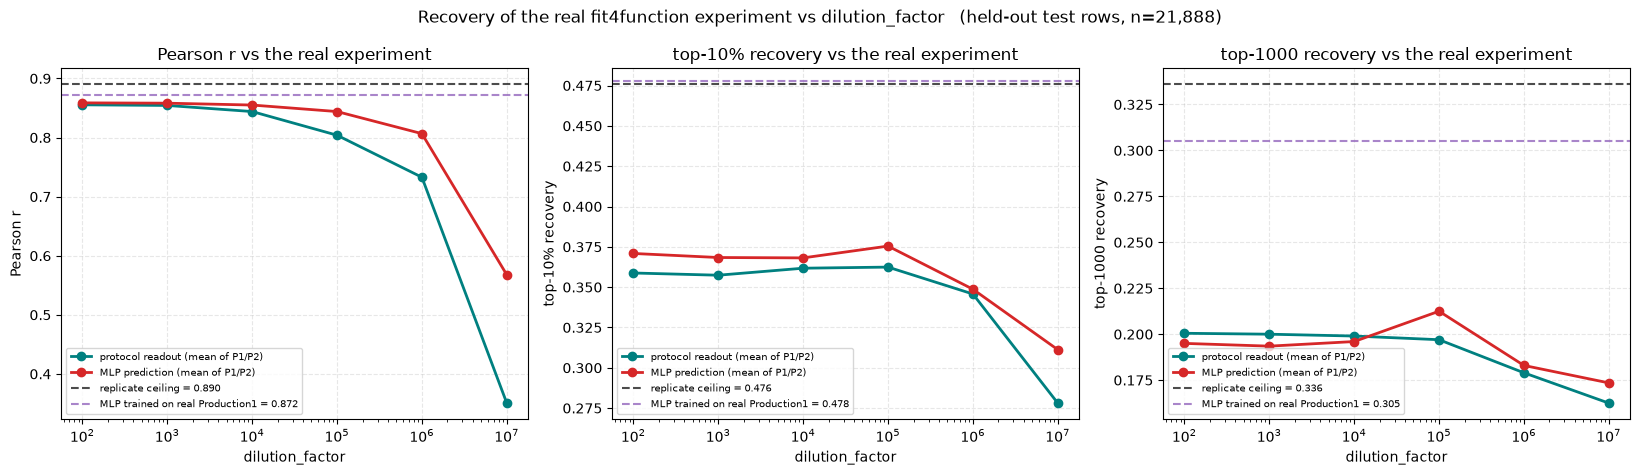

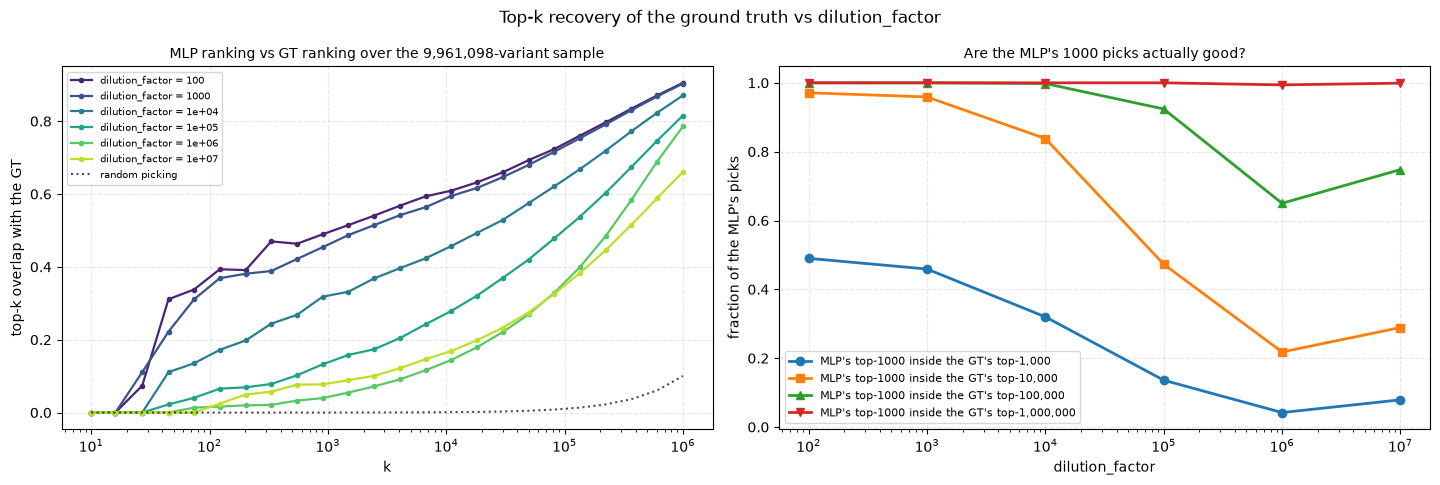

In [13]:
show_sweep(res_dilution, "dilution_factor", logx=True)

## 6. Sweep -- initial diversity (library size `d0`)

Every other sweep varies a protocol knob while the library is fixed at the full 74,464
`fit4function` variants. This one varies the **library itself**: at each point the real library
is randomly subsampled to `d0` variants (fixed seed, drawn independently per `d0`), and the
whole pipeline is rebuilt on that subsample -- new train/test split, new protocol, a fresh MLP.

`mu` is held at the baseline, so `N1 = mu * d0 / rho` and `N0 = 150 * N1` shrink with `d0`.
**`D` is held fixed** (not scaled with `d0`), so reads per variant = `D / d0` *rises* as the
library shrinks -- this sweep measures "a smaller library, same total sequencing budget", i.e.
the trade between diversity and per-variant depth, not diversity in isolation.

**Figure 3 (MLP ranking vs the GT over the fixed 10M-variant sample) is the diversity-comparable
one** -- the sample never changes, so every point is scored on identical ground. Figures 1-2 use
each subsample own held-out test rows, whose count falls with `d0` (~`0.73 * 0.40 * d0`
both-replicate-valid rows): at the smallest grid points the test fold drops below `TOP_K`, so
figure 2 top-1000 panel saturates at 1.0 for readout and ceiling alike and carries no signal
there -- read Pearson r and top-10% at small `d0`, and lean on figure 3.


In [14]:
D0_FULL = d0                       # 74,464 -- the full fit4function library
DIVERSITY_SUBSAMPLE_SEED = 1234


def _diversity_subsample(d0_sub):
    """Indices of a random d0_sub-row subset of the full library (fixed seed)."""
    if d0_sub >= D0_FULL:
        return np.arange(D0_FULL)
    rng = np.random.default_rng(DIVERSITY_SUBSAMPLE_SEED)
    return np.sort(rng.choice(D0_FULL, size=d0_sub, replace=False))


def evaluate_diversity_point(d0_sub, seed=0, verbose=True):
    """Like evaluate_point, but the swept quantity is the library size. Rebuilds the library,
    the split, the protocol and the MLP on a d0_sub-row subsample; the 10M sequence-space
    sample and the GT are untouched, so figure 3 stays comparable across points."""
    t_start = time.time()
    sub  = _diversity_subsample(d0_sub)
    sm   = seq_matrix[sub]
    soh  = seq_oh[sub]
    seqj = jnp.asarray(sm)
    bv   = both_valid[sub]
    l2p1, l2p2 = log2_p1[sub], log2_p2[sub]

    itr, ite = train_test_split(np.arange(len(sub)), train_size=0.60, random_state=0)
    _p   = np.random.default_rng(0).permutation(len(itr))
    _nv  = int(0.15 * len(itr))
    ival, ifit = itr[_p[:_nv]], itr[_p[_nv:]]
    tv   = bv[ite]
    itev = ite[tv]
    rp1, rp2 = l2p1[itev], l2p2[itev]

    N1 = BASELINE["mu"] * len(sub) / RHO_REF
    protocol = ProtocolCrossPackagingBackground(
        multinomialNGS=True, key=jax.random.key(seed), N0=N0_OVER_N1 * N1, N1=N1,
        dilution_factor=BASELINE["dilution_factor"], sequences=seqj, D=BASELINE["D"],
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel_zero, J_sel=J_sel_zero,
        noise_viab=BASELINE["noise_viab"], noise_sel=0.0, T_sel=T_SEL, T_viab=BASELINE["T_viab"],
        rho=RHO_REF, cross_packaging_rate=BASELINE["cross_packaging_rate"],
    )
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio, ngs = protocol.loop_DE()
    l0p, l2p, _l3 = (np.asarray(a) for a in ngs)
    target = np.log2((l2p + EPS) / (l0p + EPS))

    model, val_mse, best_epoch = train_mlp(target, seed=seed, fit_idx=ifit, val_idx=ival, x_oh=soh)
    pred = np.asarray(predict_log_enrichment(model, jnp.asarray(soh)))

    proto_test, mlp_test = target[itev], pred[itev]
    out = dict(param="diversity", value=d0_sub, config=dict(BASELINE, d0=d0_sub),
               val_mse=val_mse, best_epoch=best_epoch,
               proto_test=proto_test, mlp_test=mlp_test,
               real_p1_test=rp1, real_p2_test=rp2, n_test=int(len(rp1)),
               ceiling=dict(r=pearson(rp1, rp2),
                            prec10=precision_at_k(rp1, rp2, k_frac=0.10),
                            top1000=topk_recovery(rp1, rp2, k=TOP_K)))

    # --- 1. recovery of the REAL experiment (this subsample's held-out test rows) ---
    for name, v in (("proto", proto_test), ("mlp", mlp_test)):
        for rep, real in (("p1", rp1), ("p2", rp2)):
            out[f"r_{name}_{rep}"]       = pearson(v, real)
            out[f"prec10_{name}_{rep}"]  = precision_at_k(real, v, k_frac=0.10)
            out[f"top1000_{name}_{rep}"] = topk_recovery(v, real, k=TOP_K)
        for metric in ("r", "prec10", "top1000"):
            out[f"{metric}_{name}"] = 0.5 * (out[f"{metric}_{name}_p1"] + out[f"{metric}_{name}_p2"])

    # --- 2. the MLP over the fixed 10M sample (identical to evaluate_point) ---
    scan_pred = mlp_scan(model)
    top_pos   = mlp_top_k(scan_pred)
    top_gt    = SCAN_GT[top_pos]
    top_rank  = GT_RANK[top_pos]
    out.update(
        top_idx=SCAN_IDX[top_pos], top_pred=scan_pred[top_pos], top_gt=top_gt, top_gt_rank=top_rank,
        gt_median_of_mlp_top=float(np.median(top_gt)), gt_max_of_mlp_top=float(top_gt.max()),
        r_mlp_vs_gt_sample=pearson(scan_pred, SCAN_GT),
        recovery_k=K_GRID, recovery_curve=topk_overlap_curve(scan_pred),
        n_top_beating_real_library=int((top_gt > REAL_LIB_GT.max()).sum()),
    )
    for k in GT_RECOVERY_DEPTHS:
        out[f"gt_recovery_top{k}"] = float(np.mean(top_rank < k))
    out["gt_top1000_overlap"] = out["gt_recovery_top1000"]

    out["elapsed"] = time.time() - t_start
    if verbose:
        print(f"  d0={d0_sub:<8,} r_proto={out['r_proto']:+.3f} r_mlp={out['r_mlp']:+.3f} "
              f"top{TOP_K}_mlp={out['top1000_mlp']:.3f} | sample: r(MLP,GT)="
              f"{out['r_mlp_vs_gt_sample']:+.3f}  GT median of its top-{TOP_K}="
              f"{out['gt_median_of_mlp_top']:+.2f}  top-{TOP_K} overlap w/ GT="
              f"{out['gt_top1000_overlap']:.1%}  [{out['elapsed']:.0f}s]")
    return out


def run_diversity_sweep(values, seed=0):
    print(f"=== sweep: initial diversity d0  (everything else at baseline {BASELINE}) ===")
    results = [evaluate_diversity_point(v, seed=seed) for v in values]
    print(f"=== done, {sum(r['elapsed'] for r in results) / 60:.1f} min ===")
    return results

In [15]:
def plot_distributions_diversity(results, bins=70):
    """Figure 1 for the diversity sweep: each panel overlays THAT subsample's own real
    Production1 test rows (they differ per d0) vs its protocol and its MLP, median-aligned."""
    n = len(results)
    fig, axes = plt.subplots(2, n, figsize=(3.6 * n, 7.2))
    axes = np.atleast_2d(axes).reshape(2, n)
    rows = [("proto_test", "protocol", PROTO_COLOR), ("mlp_test", "MLP prediction", MLP_COLOR)]
    for col, res in enumerate(results):
        real = res["real_p1_test"]
        for row, (key, label, color) in enumerate(rows):
            v = res[key]
            shift = float(np.median(real) - np.median(v))
            vs = v + shift
            ax = axes[row, col]
            rng = (min(real.min(), vs.min()), max(real.max(), vs.max()))
            b = np.linspace(*rng, bins)
            ax.hist(real, bins=b, alpha=0.5, density=True, color=REAL_COLOR, label="real Production1")
            ax.hist(vs, bins=b, alpha=0.5, density=True, color=color, label=f"{label} (shift {shift:+.1f})")
            ax.set_xlabel("log2 enrichment")
            if col == 0:
                ax.set_ylabel(f"density -- real vs {label}")
            ax.set_title(f"d0 = {res['value']:,}   (n_test = {res['n_test']:,})", fontsize=9)
            ax.grid(True, ls="--", alpha=0.3)
            ax.legend(fontsize=7)
    fig.suptitle("Log2 enrichment -- real vs protocol (top) and real vs MLP (bottom), sweeping initial diversity d0\n"
                 "(each panel: that subsample's own held-out test rows, median-aligned to its real Production1)")
    fig.tight_layout()
    plt.show()


def plot_recovery_diversity(results):
    """Figure 2 for the diversity sweep. The replicate ceiling shrinks with d0 (fewer test
    rows with a real measurement), so it is a per-point curve here, not a flat line. The
    real-data-trained MLP baseline (section 4f) was fitted once on the full library and is
    left as its flat reference."""
    x = np.array([r["value"] for r in results], dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    panels = [("r", "Pearson r"), ("prec10", "top-10% recovery"), ("top1000", f"top-{TOP_K} recovery")]
    for ax, (metric, title) in zip(axes, panels):
        for name, color, lab in [("proto", PROTO_COLOR, "protocol readout"),
                                 ("mlp", MLP_COLOR, "MLP prediction")]:
            ax.plot(x, [r[f"{metric}_{name}"] for r in results], "o-", color=color, lw=2,
                    label=f"{lab} (mean P1/P2)")
        ax.plot(x, [r["ceiling"][metric] for r in results], "s--", color="black", alpha=0.7,
                label="replicate ceiling (this d0)")
        ax.axhline(REAL_MLP_BASELINE[metric], color="tab:purple", ls="--", alpha=0.8,
                   label=f"MLP on real Production1 (full lib) = {REAL_MLP_BASELINE[metric]:.3f}")
        ax.set_xscale("log")
        ax.set_xlabel("initial diversity d0")
        ax.set_ylabel(title)
        ax.set_title(f"{title} vs the real experiment")
        ax.legend(fontsize=7)
        ax.grid(True, ls="--", alpha=0.3)
    fig.suptitle("Recovery of the real fit4function experiment vs initial diversity d0")
    fig.tight_layout()
    plt.show()


def show_diversity_sweep(results):
    plot_distributions_diversity(results)
    plot_recovery_diversity(results)
    plot_topk_recovery(results, "diversity (d0)", logx=True)

In [16]:
GRID_DIVERSITY = [2_000, 5_000, 10_000, 20_000, 40_000, d0]   # d0 = 74,464 = full library
res_diversity  = run_diversity_sweep(GRID_DIVERSITY)
summarize(res_diversity)

=== sweep: initial diversity d0  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   2%|▎         | 1/40 [00:00<00:28,  1.35it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 47.18it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 45.16it/s]

  d0=74,464   r_proto=+0.733 r_mlp=+0.807 top1000_mlp=0.183 | sample: r(MLP,GT)=+0.891  GT median of its top-1000=+7.73  top-1000 overlap w/ GT=4.2%  [38s]
=== done, 2.4 min ===


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s
0,diversity,2000,0.7145,0.6132,0.7015,0.6144,0.2586,0.1897,1.0000,1.0000,0.7986,6.7839,0.005,0.062,0.322,0.876,3,46.8551,15.7446
1,diversity,5000,0.7285,0.7112,0.7317,0.7141,0.3069,0.2586,0.8110,0.8430,0.8454,6.5146,0.011,0.063,0.282,0.816,6,27.8743,17.5622
2,diversity,10000,0.7229,0.7417,0.7274,0.7375,0.3468,0.2643,0.7400,0.7300,0.8637,7.2001,0.024,0.124,0.440,0.924,11,17.7599,19.4433
3,diversity,20000,0.7233,0.7675,0.7247,0.7660,0.3302,0.3007,0.4990,0.4670,0.8820,8.0335,0.088,0.319,0.778,0.999,47,13.9964,23.0028
4,diversity,40000,0.7272,0.7949,0.7267,0.7946,0.3328,0.3409,0.2995,0.3005,0.8842,7.5576,0.040,0.188,0.576,0.994,28,9.9591,33.2928
5,diversity,74464,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.1790,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,37.8649


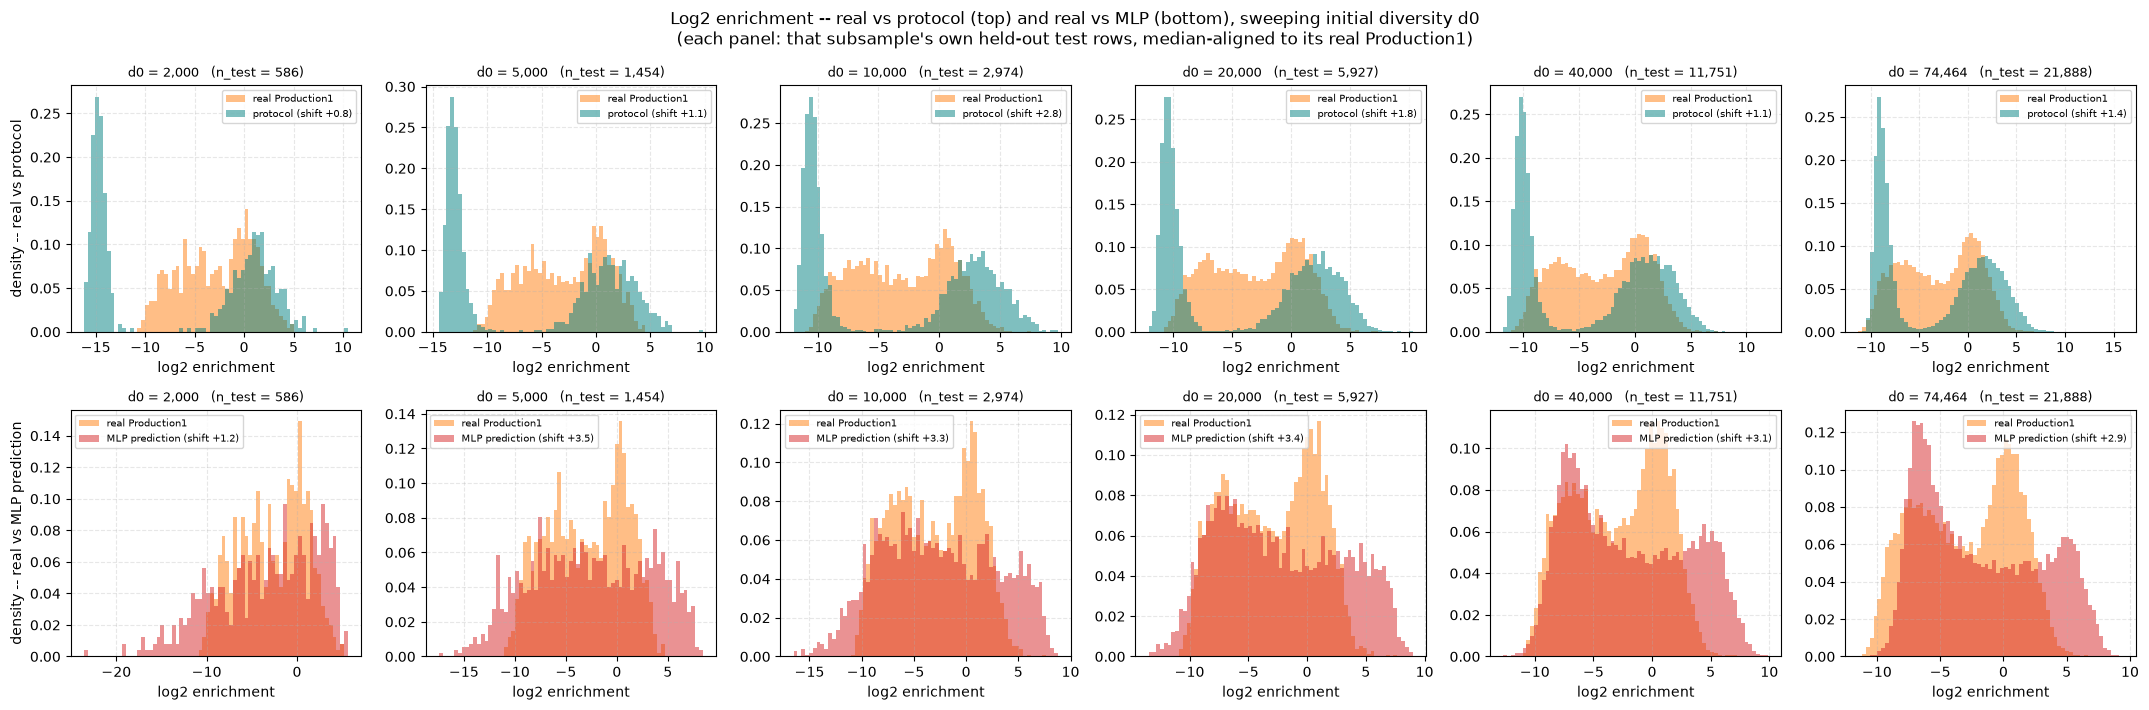

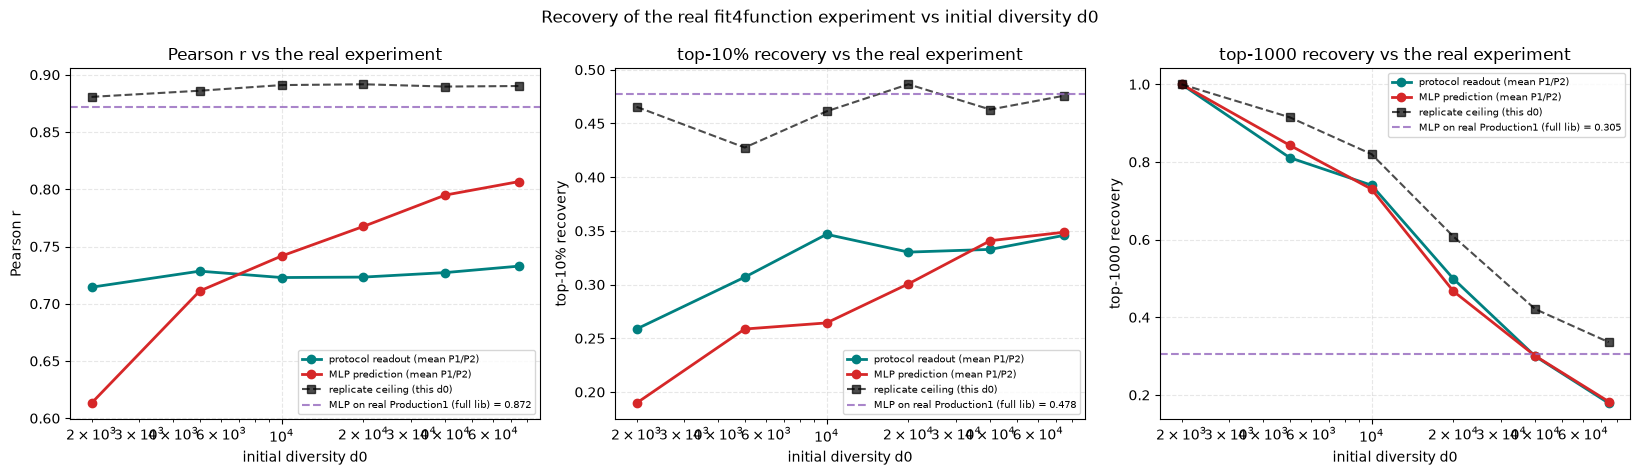

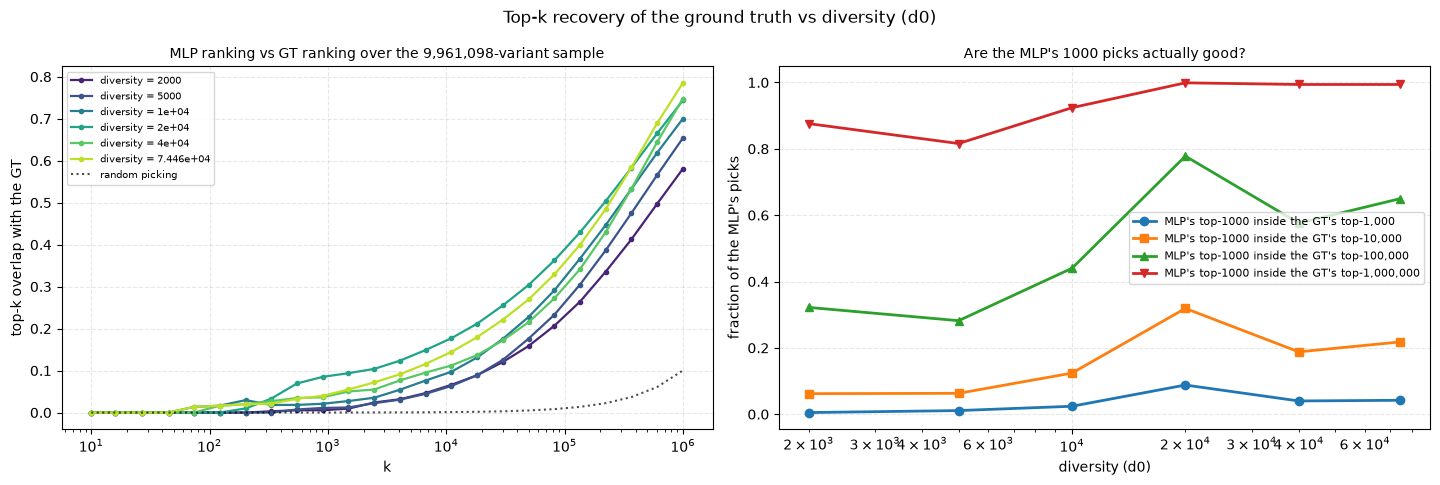

In [17]:
show_diversity_sweep(res_diversity)

## 7. Sweep -- `cross_packaging_rate`

The leakage floor `ProtocolCrossPackagingBackground` adds to every sequence's capsid production rate. `cross_packaging_rate = 0` is plain `ProtocolV3`, so the first point is the un-perturbed baseline.

In [18]:
GRID_CROSS_PACKAGING_RATE = [0.0, 0.01, 0.05, 0.15, 0.30, 0.50]
res_cross_packaging_rate = run_sweep("cross_packaging_rate", GRID_CROSS_PACKAGING_RATE)
summarize(res_cross_packaging_rate)

=== sweep: cross_packaging_rate  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles: 100%|██████████| 40/40 [00:00<00:00, 399.75it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 47.11it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 47.09it/s]

  cross_packaging_rate=0.5        r_proto=+0.705 r_mlp=+0.793 top1000_mlp=0.202 | sample: r(MLP,GT)=+0.878  GT median of its top-1000=+7.53 (GT's own: +9.49)  top-1000 overlap with GT=2.6%  [38s]
=== done, 3.9 min ===


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s
0,cross_packaging_rate,0.00,0.7369,0.8080,0.7367,0.8090,0.3444,0.3521,0.1790,0.1925,0.8914,7.7411,0.039,0.203,0.639,0.997,21,7.4620,37.5046
1,cross_packaging_rate,0.01,0.7358,0.8076,0.7356,0.8085,0.3446,0.3510,0.1790,0.1835,0.8911,7.6813,0.031,0.194,0.622,0.994,17,7.5196,40.5423
2,cross_packaging_rate,0.05,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.1790,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,40.1761
3,cross_packaging_rate,0.15,0.7258,0.8035,0.7256,0.8042,0.3430,0.3478,0.1805,0.1895,0.8888,7.7882,0.043,0.211,0.662,0.999,22,8.2164,38.2172
4,cross_packaging_rate,0.30,0.7171,0.7971,0.7171,0.7977,0.3407,0.3505,0.1805,0.1960,0.8825,7.7873,0.034,0.240,0.671,0.998,21,8.9539,38.3926
5,cross_packaging_rate,0.50,0.7054,0.7929,0.7051,0.7929,0.3430,0.3526,0.1790,0.2015,0.8778,7.5304,0.026,0.176,0.561,0.996,11,9.7345,37.8389


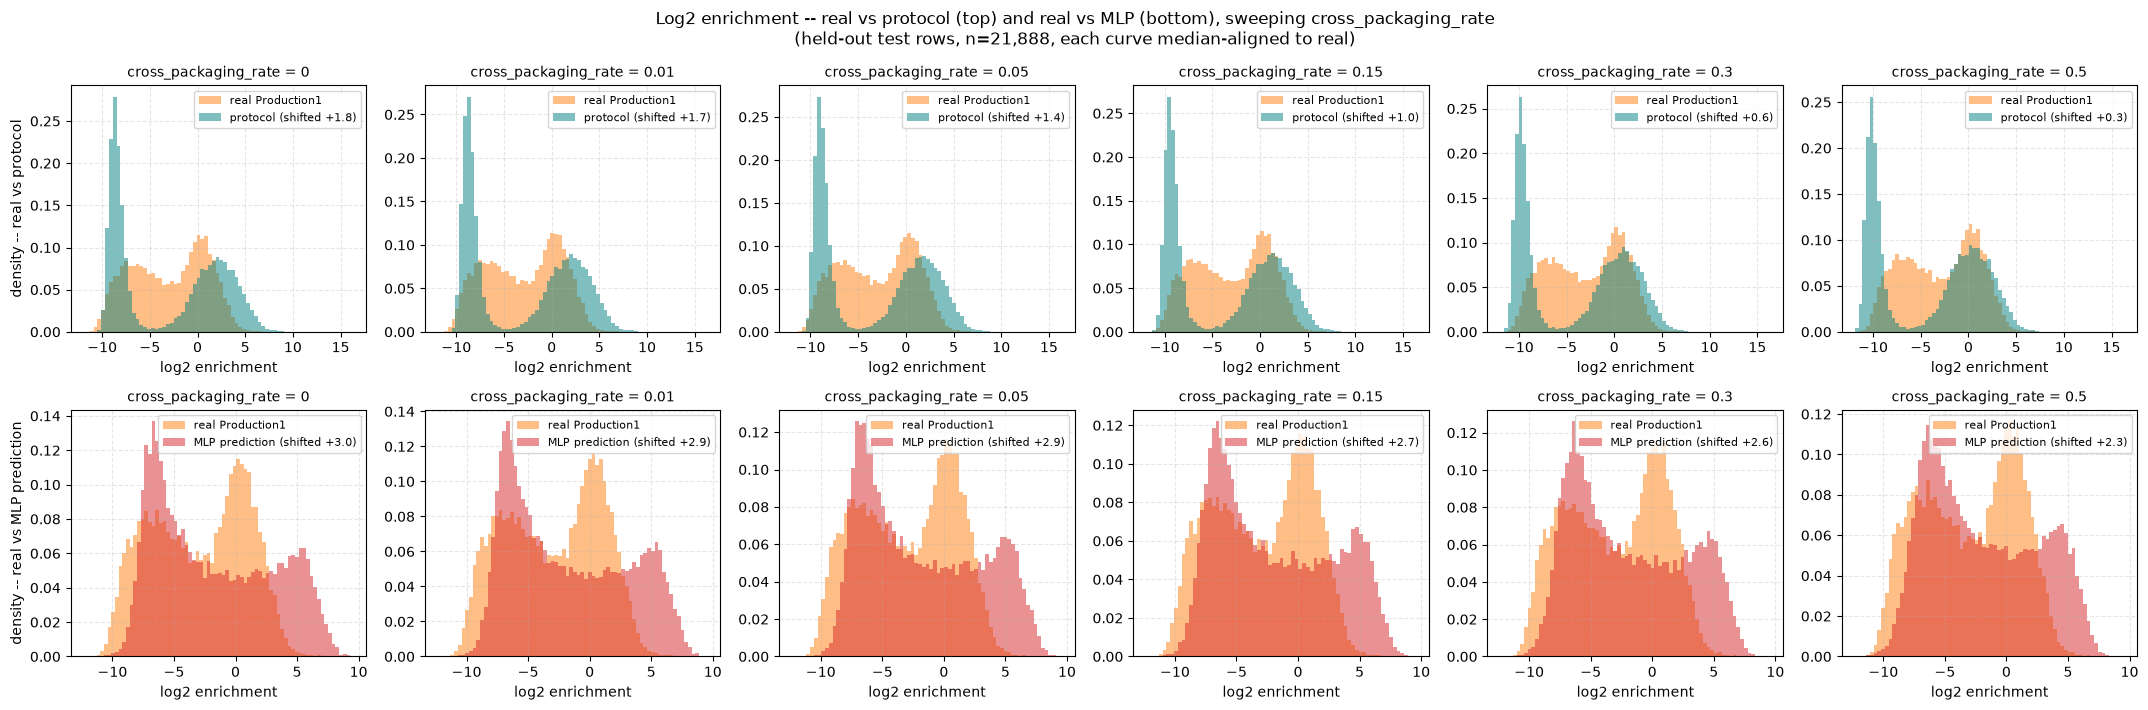

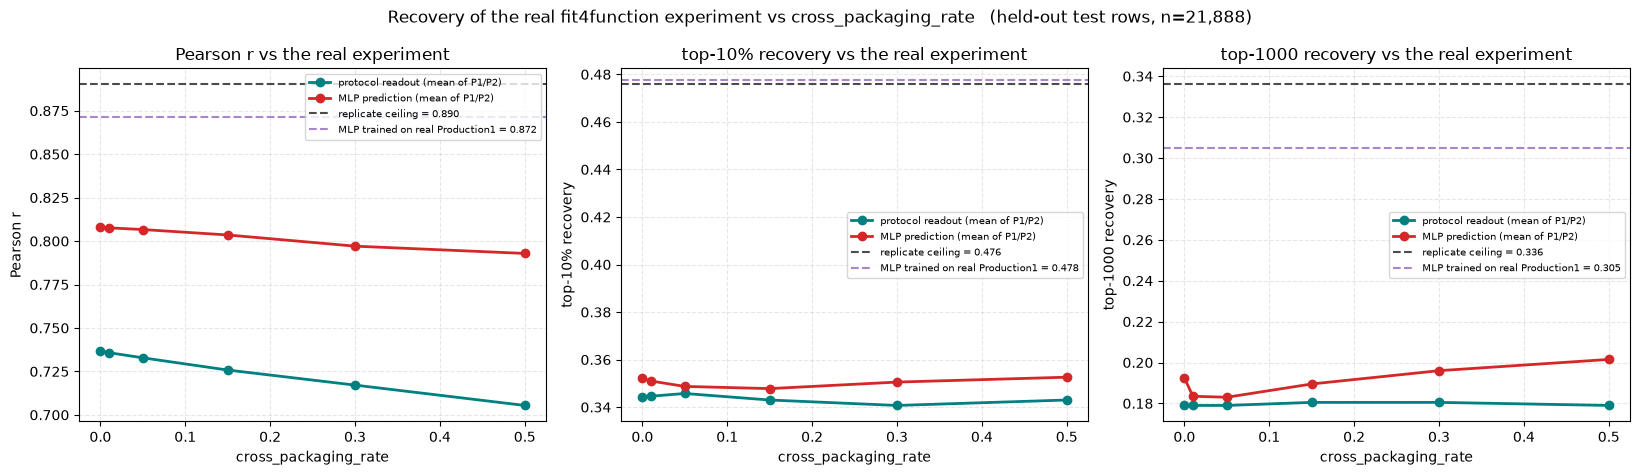

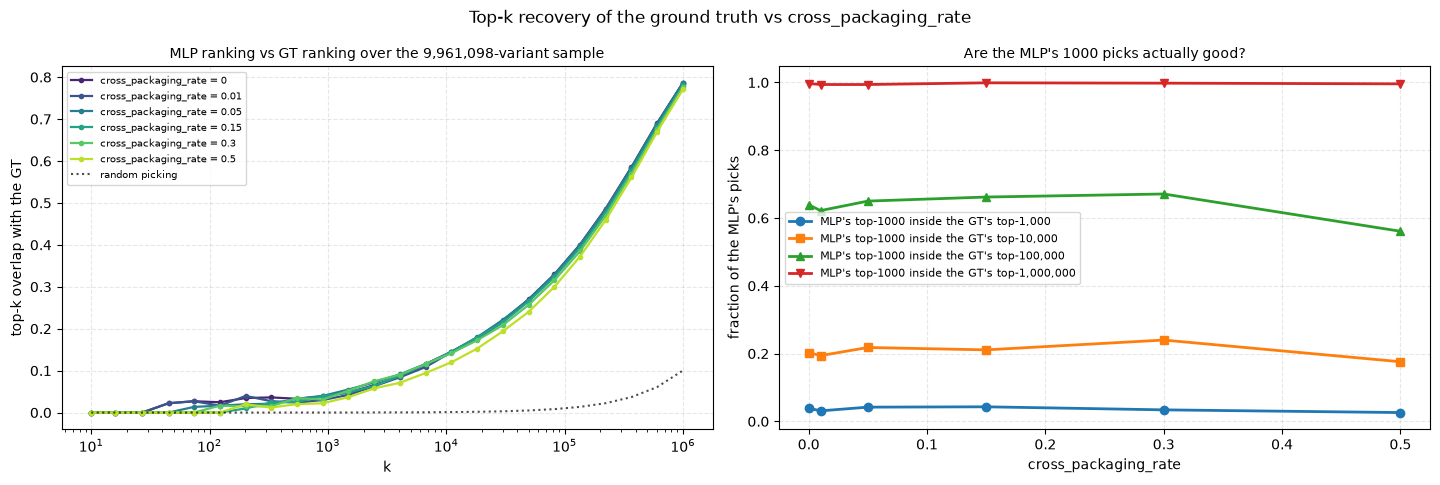

In [19]:
show_sweep(res_cross_packaging_rate, "cross_packaging_rate", logx=False)

## 8. Sweep -- `mu`

Transfected HEK cells per sequence, set through `N1 = mu * d0 / rho` with `N0 = 150 * N1`. Low `mu` lets the per-cell `noise_viab` lottery dominate; high `mu` averages it out. The grid stops at `mu = 200` (`N0 = 2.2e12`, near the practical ceiling `CLAUDE.md` records).

In [20]:
GRID_MU = [1, 5, 10, 25, 50, 100, 200]
res_mu = run_sweep("mu", GRID_MU)
summarize(res_mu)

=== sweep: mu  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

...

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 45.37it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 45.48it/s]

  mu=200        r_proto=+0.791 r_mlp=+0.839 top1000_mlp=0.213 | sample: r(MLP,GT)=+0.938  GT median of its top-1000=+8.24 (GT's own: +9.49)  top-1000 overlap with GT=10.6%  [41s]
=== done, 4.7 min ===


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s
0,mu,1,0.1731,0.3273,0.1749,0.3272,0.2377,0.2605,0.1590,0.1430,0.3786,7.4245,0.018,0.112,0.539,0.983,8,28.6086,36.8755
1,mu,5,0.3372,0.5583,0.3376,0.5589,0.2754,0.3144,0.1605,0.1725,0.6330,7.8637,0.074,0.257,0.685,0.997,48,42.7578,37.4803
2,mu,10,0.4580,0.6380,0.4586,0.6395,0.2786,0.3179,0.1375,0.1670,0.7132,7.6681,0.037,0.183,0.658,0.998,18,32.3840,37.2497
3,mu,25,0.6544,0.7619,0.6536,0.7631,0.3138,0.3250,0.1490,0.1735,0.8479,7.9118,0.059,0.267,0.712,0.999,40,12.4105,41.6490
4,mu,50,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.1790,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,42.0661
5,mu,100,0.7675,0.8295,0.7678,0.8298,0.3601,0.3654,0.1920,0.2135,0.9204,7.9403,0.069,0.306,0.737,1.000,42,6.5266,43.7633
6,mu,200,0.7908,0.8392,0.7911,0.8391,0.3654,0.3725,0.1945,0.2135,0.9384,8.2355,0.106,0.397,0.862,1.000,61,5.2441,41.2426


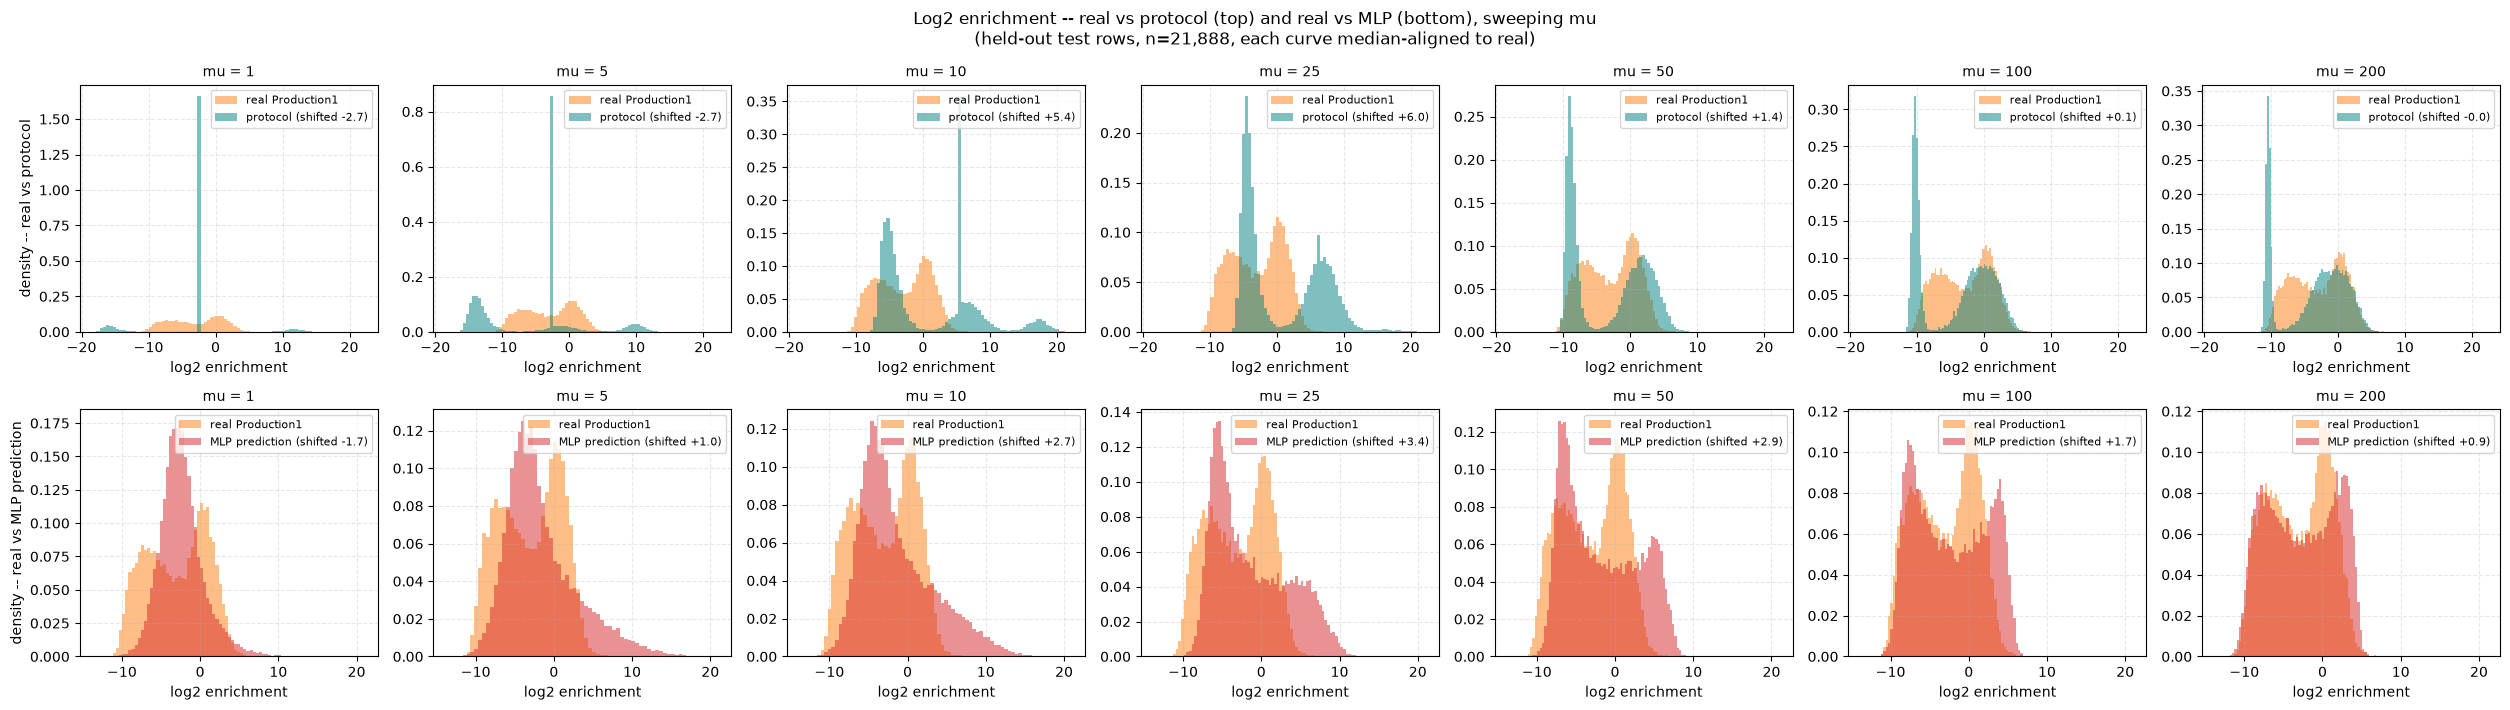

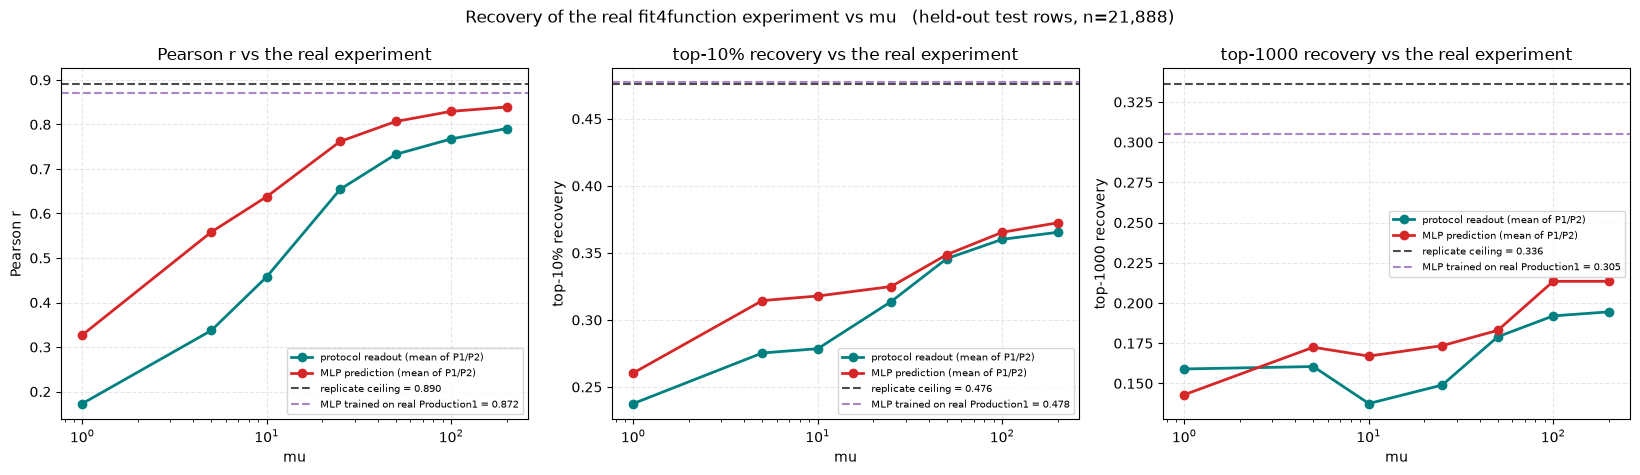

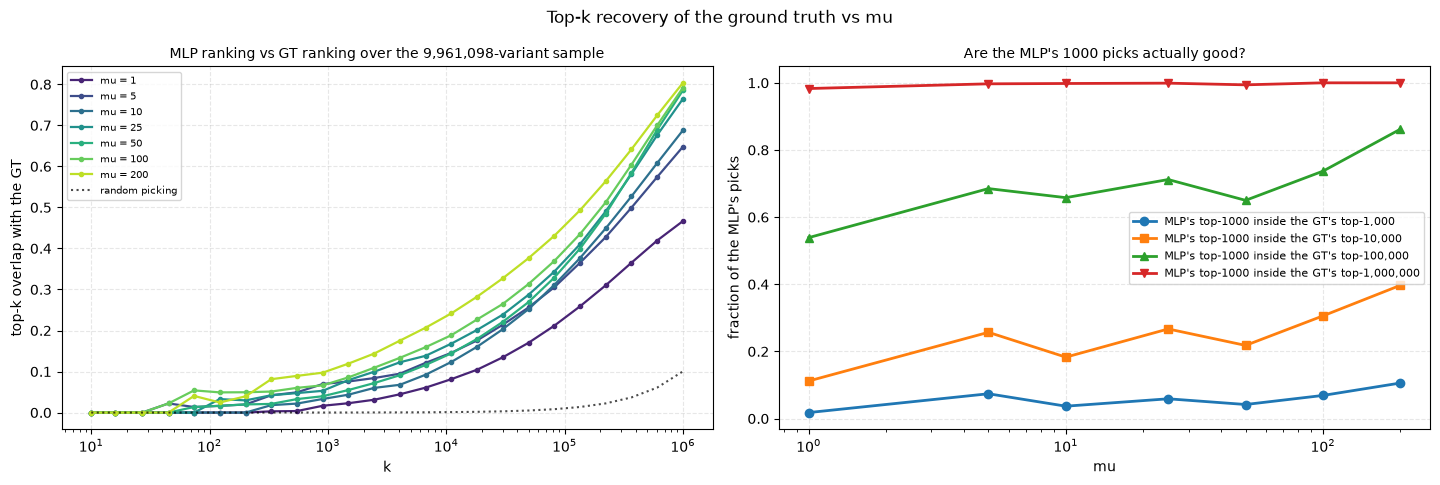

In [21]:
show_sweep(res_mu, "mu", logx=True)

## 9. Sweep -- `T_viab`

Sharpness of `exp(score / T_viab)` in `produce_capsids()`. Low `T_viab` inflates the signal-to-noise ratio (it scales the score, not the noise); high `T_viab` flattens selection. `1.3` is the Potts-GT baseline; `0.8` is only the value derived for the old naive GT.

In [22]:
GRID_T_VIAB = [0.4, 0.8, 1.3, 2.0, 4.0, 8.0]
res_T_viab = run_sweep("T_viab", GRID_T_VIAB)
summarize(res_T_viab)

=== sweep: T_viab  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

...

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 46.71it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 48.10it/s]

  T_viab=8          r_proto=+0.146 r_mlp=+0.321 top1000_mlp=0.092 | sample: r(MLP,GT)=+0.418  GT median of its top-1000=+6.11 (GT's own: +9.49)  top-1000 overlap with GT=0.4%  [41s]
=== done, 5.2 min ===


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s
0,T_viab,0.4,0.5669,0.5967,0.5691,0.5986,0.3579,0.3421,0.1945,0.1695,0.6986,9.0571,0.347,0.875,1.000,1.000,203,1.7941,81.6818
1,T_viab,0.8,0.7920,0.8103,0.7929,0.8110,0.3528,0.3649,0.1835,0.1925,0.8879,8.8806,0.275,0.729,0.991,1.000,173,2.6974,58.4872
2,T_viab,1.3,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.1790,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,43.1981
3,T_viab,2.0,0.5946,0.7483,0.5932,0.7498,0.2936,0.3263,0.1610,0.1710,0.8519,7.6871,0.047,0.180,0.638,0.998,27,15.2730,41.8499
4,T_viab,4.0,0.3154,0.5359,0.3132,0.5384,0.2006,0.2767,0.1020,0.1415,0.6555,7.3368,0.032,0.144,0.493,0.966,19,24.0765,43.3013
5,T_viab,8.0,0.1456,0.3211,0.1435,0.3207,0.1433,0.1890,0.0695,0.0925,0.4180,6.1077,0.004,0.033,0.174,0.712,2,25.6620,41.4912


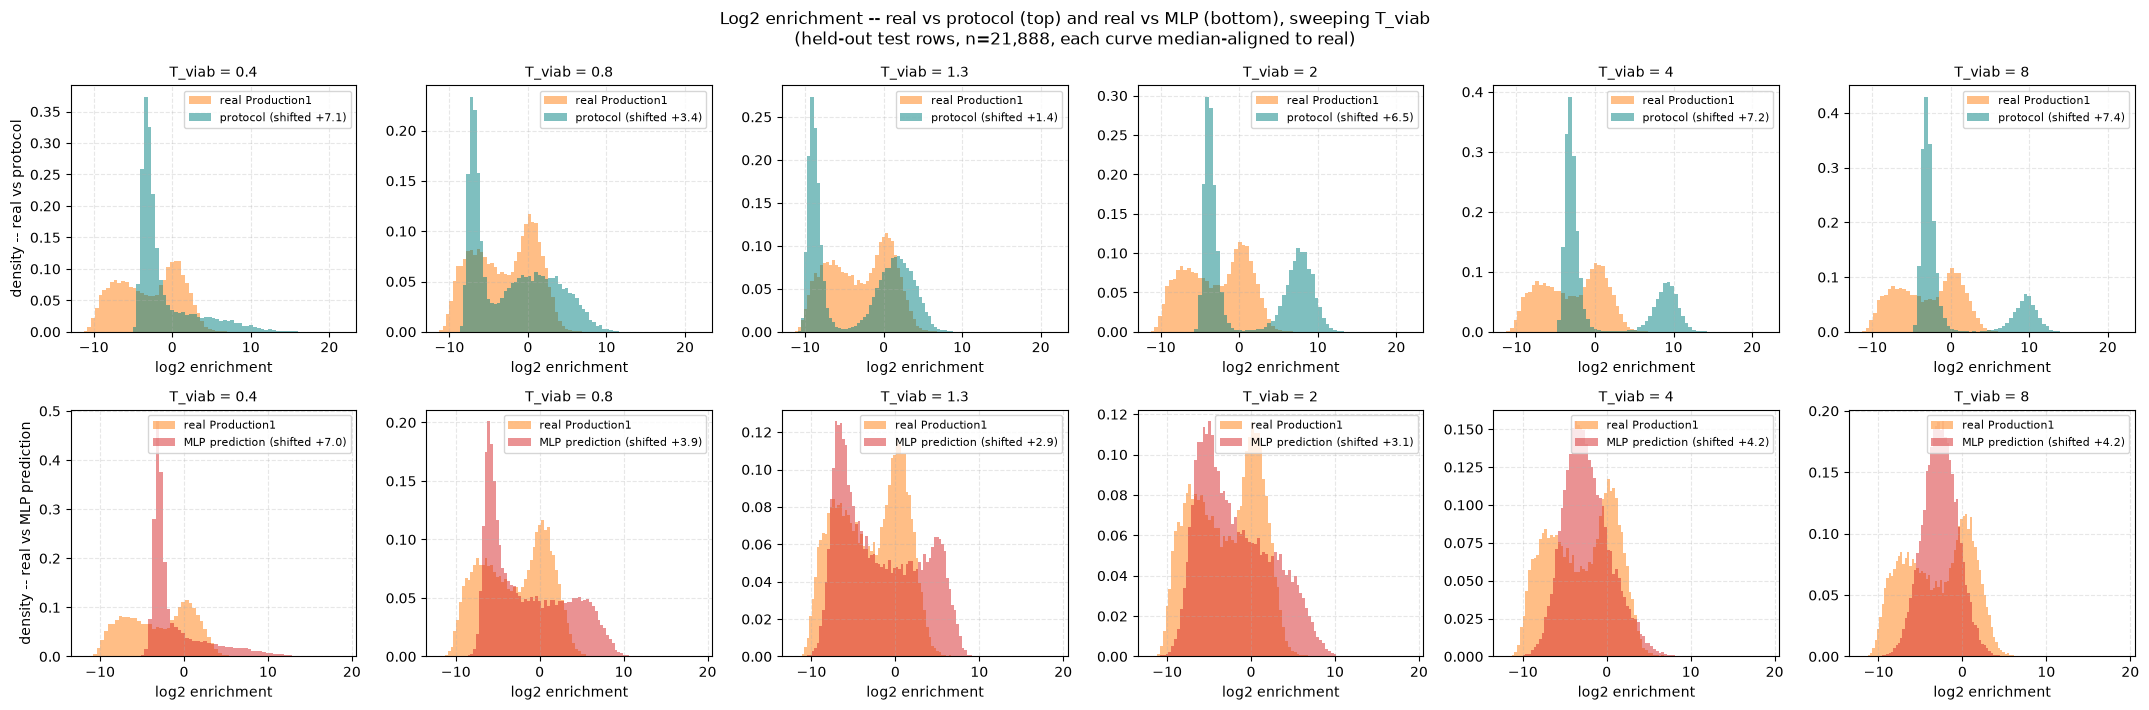

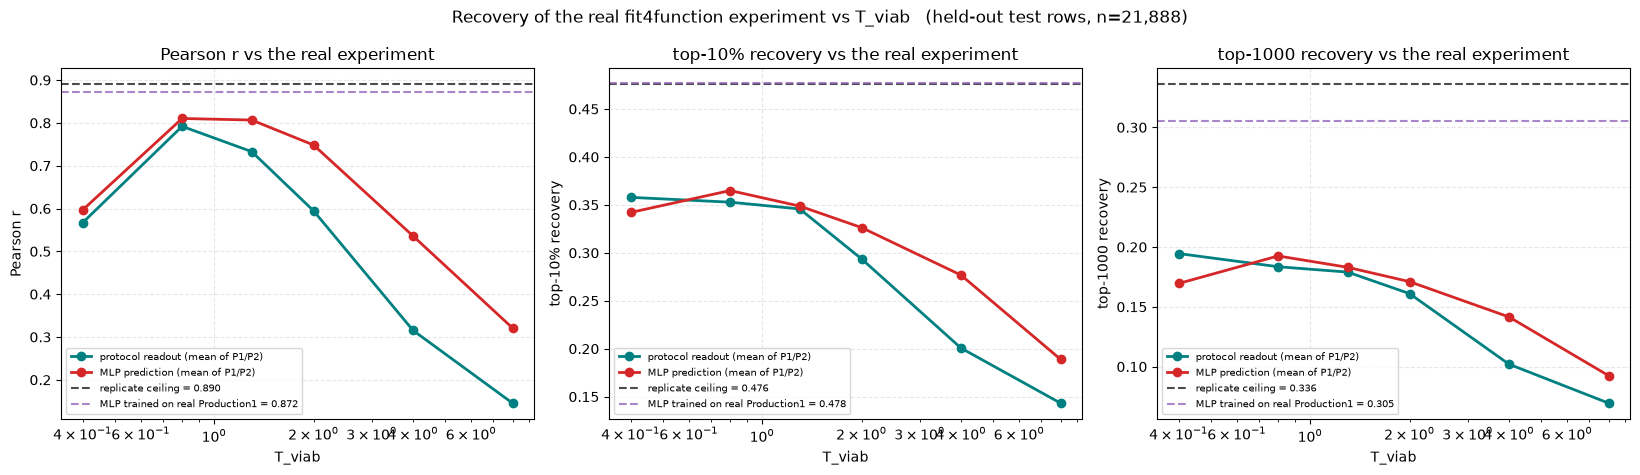

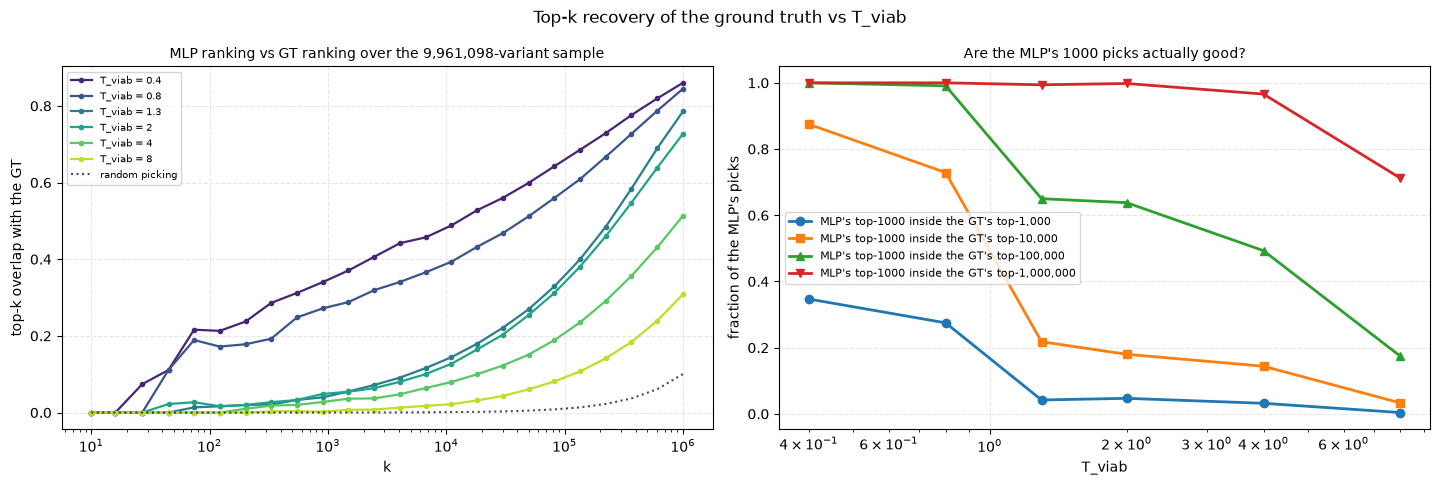

In [23]:
show_sweep(res_T_viab, "T_viab", logx=True)

## 10. Sweep -- `noise_viab`

The log-normal per-cell expression noise `exp(noise_viab * Z / T_viab)`. This is where the MLP's denoising claim is most directly testable: its figure-2 curve should stay above the protocol's as `noise_viab` grows, and its figure-3 picks should degrade more slowly.

In [24]:
GRID_NOISE_VIAB = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
res_noise_viab = run_sweep("noise_viab", GRID_NOISE_VIAB)
summarize(res_noise_viab)

=== sweep: noise_viab  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  98%|█████████▊| 39/40 [00:00<00:00, 389.69it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 44.59it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 44.25it/s]

  noise_viab=4          r_proto=+0.747 r_mlp=+0.824 top1000_mlp=0.185 | sample: r(MLP,GT)=+0.945  GT median of its top-1000=+8.18 (GT's own: +9.49)  top-1000 overlap with GT=8.4%  [47s]
=== done, 4.6 min ===


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s
0,noise_viab,0.00,0.7293,0.8025,0.7289,0.8036,0.3421,0.3464,0.1815,0.1865,0.8859,7.8196,0.049,0.233,0.675,0.994,31,7.7855,44.4232
1,noise_viab,0.25,0.7297,0.8037,0.7293,0.8050,0.3451,0.3451,0.1760,0.1865,0.8882,7.7303,0.042,0.210,0.652,0.995,26,7.7910,45.4593
2,noise_viab,0.50,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.1790,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,45.0905
3,noise_viab,1.00,0.7425,0.8099,0.7428,0.8106,0.3416,0.3430,0.1765,0.1935,0.8933,7.7814,0.047,0.236,0.648,0.997,30,7.5568,46.5403
4,noise_viab,2.00,0.7649,0.8299,0.7655,0.8299,0.3480,0.3748,0.1755,0.2090,0.9257,7.8427,0.052,0.252,0.699,0.997,39,6.4941,45.0869
5,noise_viab,4.00,0.7470,0.8237,0.7484,0.8244,0.3060,0.3478,0.1530,0.1855,0.9453,8.1774,0.084,0.340,0.848,1.000,44,4.3748,46.9333


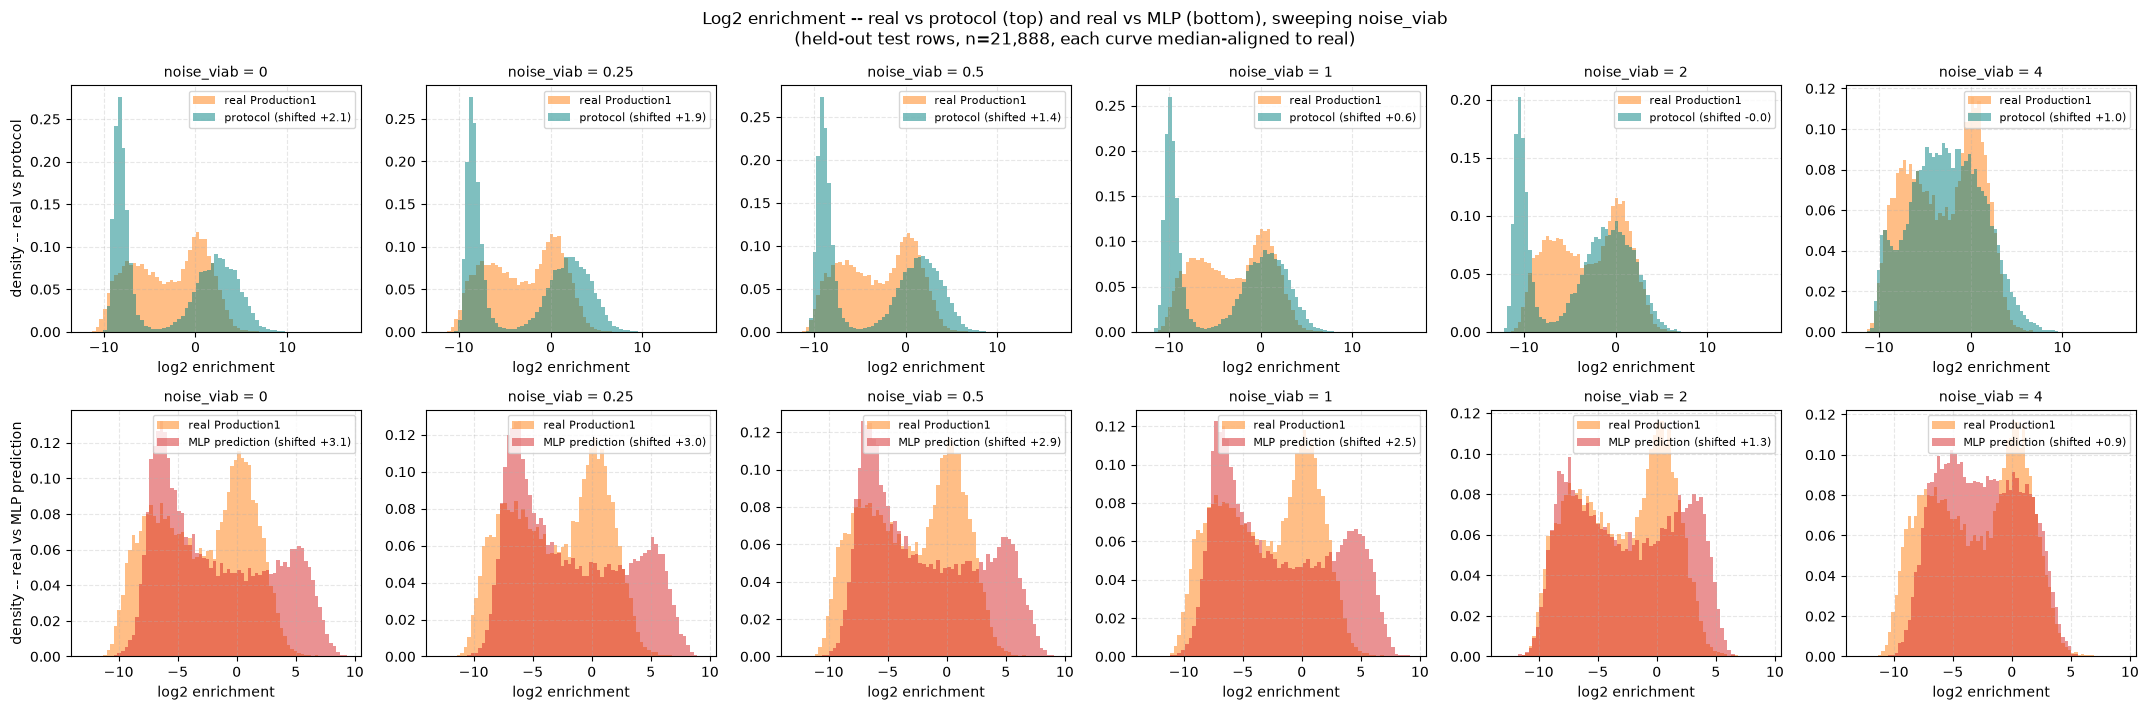

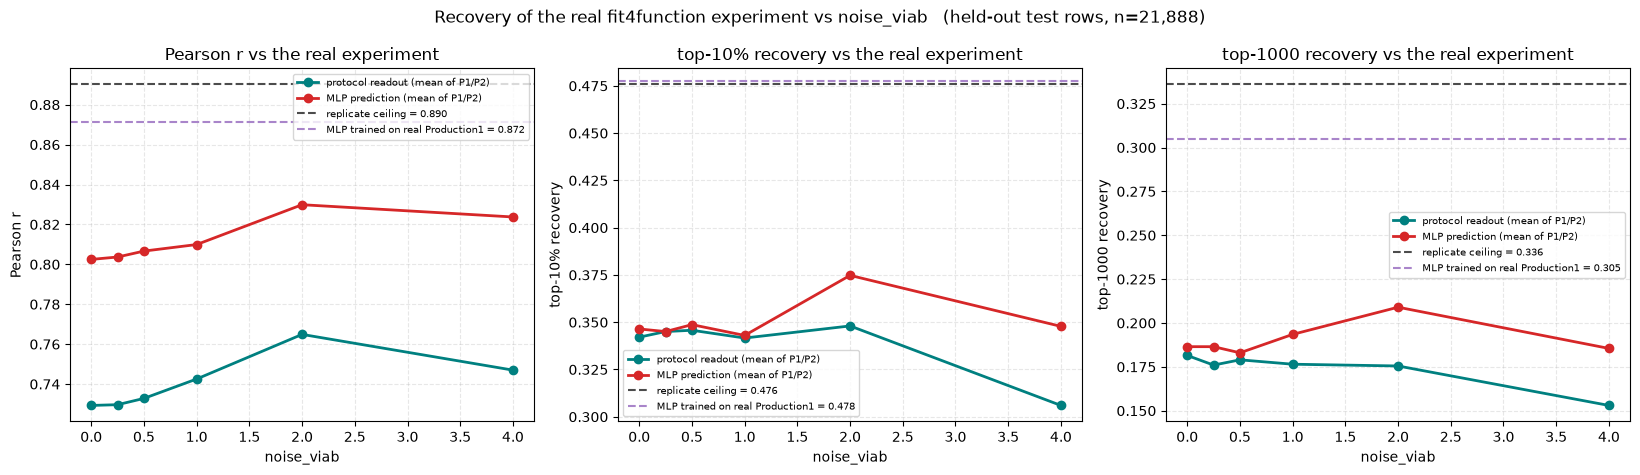

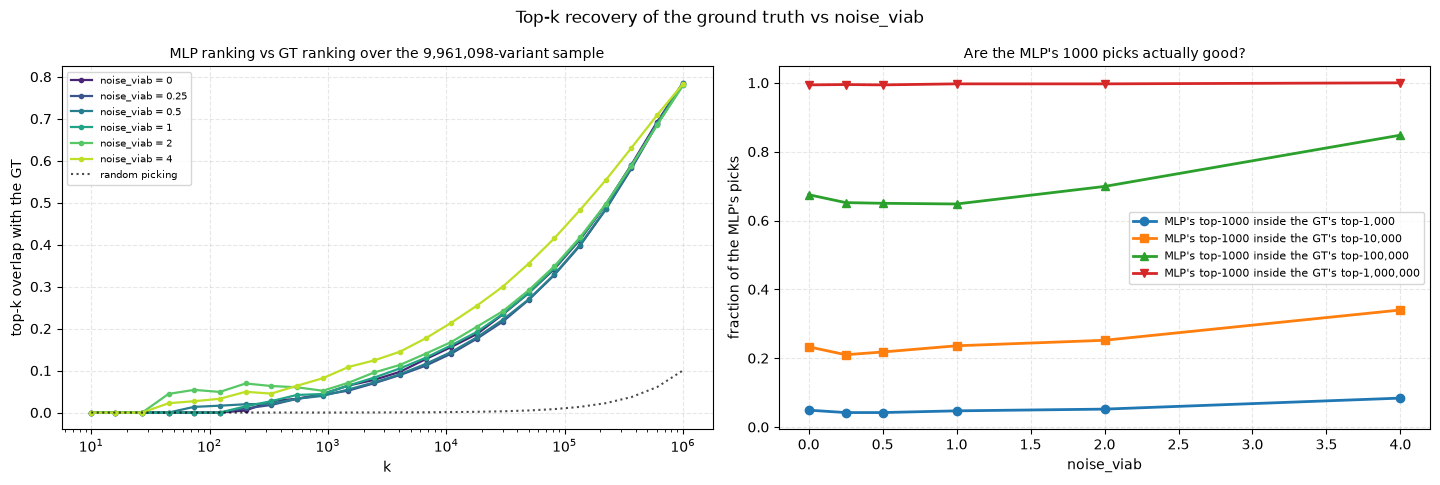

In [25]:
show_sweep(res_noise_viab, "noise_viab", logx=False)

## 11. Sweep -- `D`

NGS reads per checkpoint (`Multinomial(D, proportions)`). At `d0 = 74,464` this spans ~13 to ~13,000 reads per sequence. No pathological high end -- monotone with diminishing returns once the other noise sources dominate.

In [26]:
GRID_D = [1e6, 1e7, 1e8, 1e9]
res_D = run_sweep("D", GRID_D)
summarize(res_D)

=== sweep: D  (everything else at baseline {'dilution_factor': 1000000.0, 'mu': 50, 'T_viab': 1.3, 'noise_viab': 0.5, 'D': 100000000.0, 'cross_packaging_rate': 0.05}) ===


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  95%|█████████▌| 38/40 [00:00<00:00, 372.43it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

MLP scan (9,961,098):   0%|          | 0/10 [00:00<?, ?it/s]

MLP scan (9,961,098):  50%|█████     | 5/10 [00:00<00:00, 44.56it/s]

MLP scan (9,961,098): 100%|██████████| 10/10 [00:00<00:00, 44.07it/s]

  D=1e+09      r_proto=+0.731 r_mlp=+0.810 top1000_mlp=0.189 | sample: r(MLP,GT)=+0.893  GT median of its top-1000=+6.88 (GT's own: +9.49)  top-1000 overlap with GT=1.0%  [48s]
=== done, 3.3 min ===


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s
0,D,1.000000e+06,0.6759,0.7414,0.6764,0.7425,0.3389,0.3368,0.179,0.1670,0.8268,8.6961,0.219,0.625,0.970,1.000,136,1.7703,52.7219
1,D,1.000000e+07,0.7260,0.7888,0.7261,0.7900,0.3446,0.3350,0.177,0.1790,0.8721,8.3874,0.122,0.454,0.894,1.000,73,3.7883,49.7393
2,D,1.000000e+08,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.179,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,45.5936
3,D,1.000000e+09,0.7308,0.8104,0.7303,0.8110,0.3473,0.3426,0.182,0.1885,0.8932,6.8804,0.010,0.053,0.305,0.964,7,13.7400,47.7690


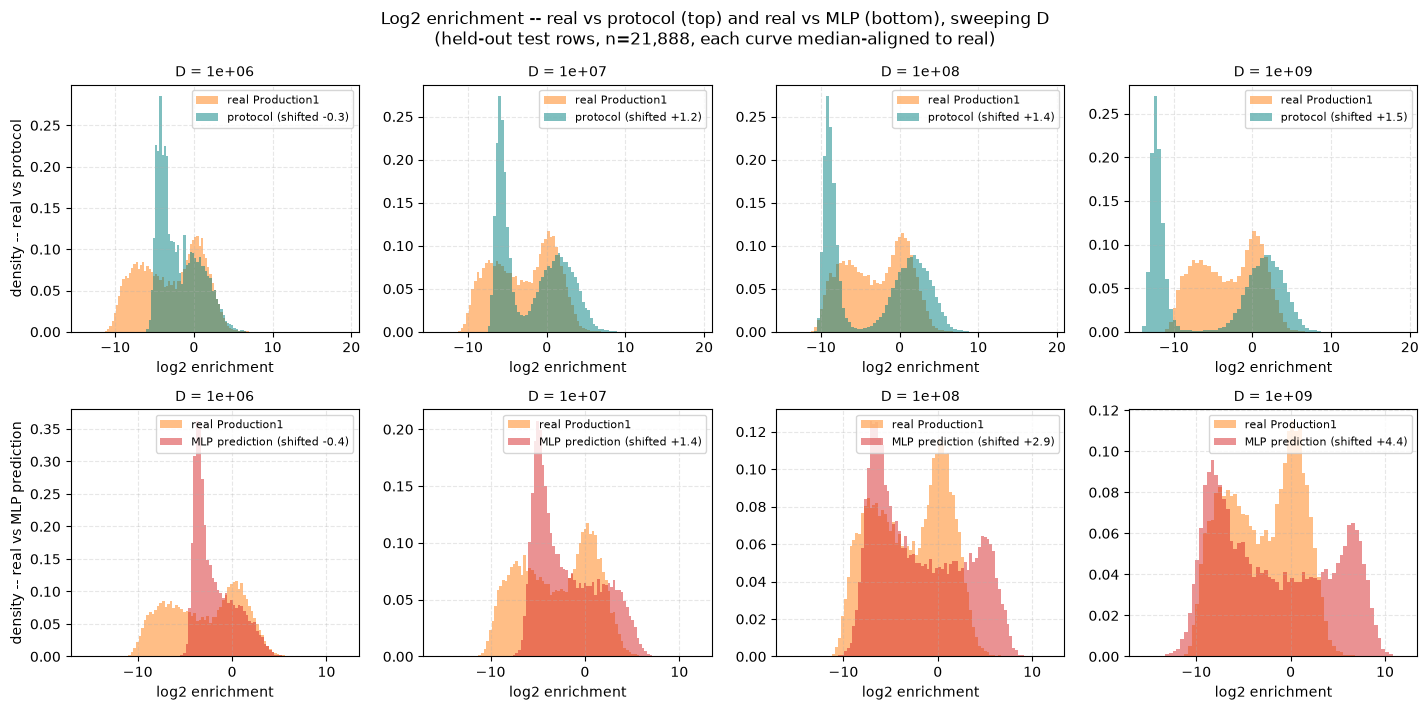

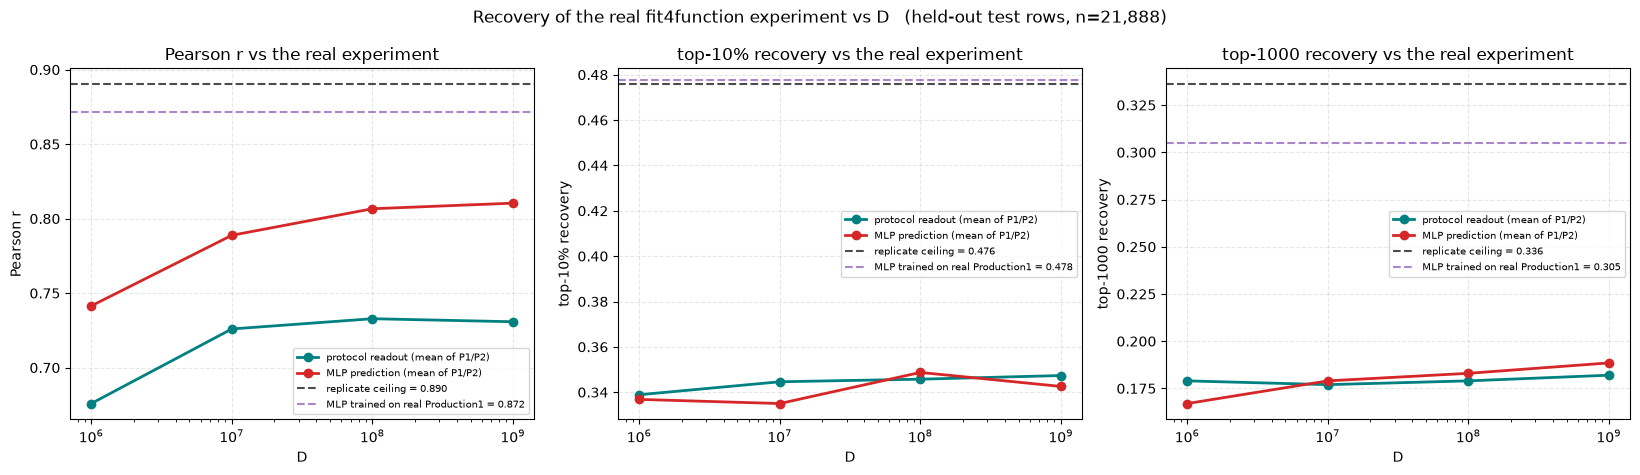

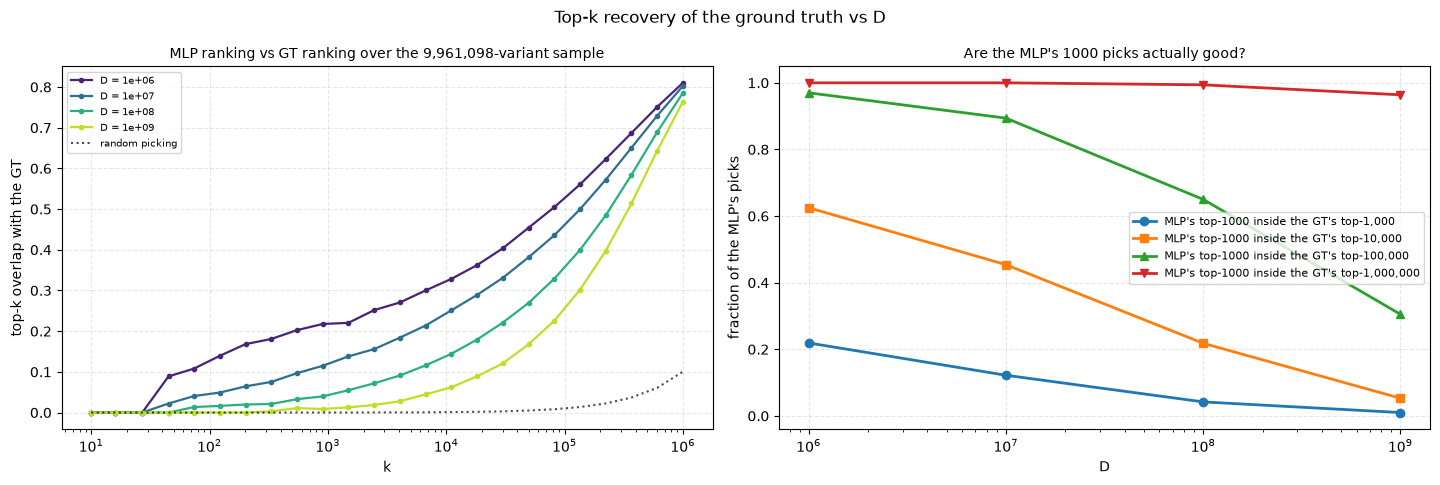

In [27]:
show_sweep(res_D, "D", logx=True)

## 12. All sweeps -- combined summary

Every sweep point run above in one frame, dumped next to the notebook so the numbers survive a kernel restart without re-running (~40-60 min on GPU). It is an export, never re-loaded automatically -- a stale copy can't silently substitute for a fresh run.

`r_* / prec10_* / top1000_*` measure how closely the simulation reproduces the **real experiment**; `r_mlp_vs_gt_sample` and `gt_recovery_top*` measure how well the MLP recovers the **ground truth** -- the actual goal. The two need not peak at the same parameter value.

In [28]:
ALL_SWEEPS = [("dilution_factor", res_dilution), ("diversity", res_diversity),
              ("cross_packaging_rate", res_cross_packaging_rate), ("mu", res_mu),
              ("T_viab", res_T_viab), ("noise_viab", res_noise_viab), ("D", res_D)]

all_results = pd.concat([summarize(r).assign(sweep=name) for name, r in ALL_SWEEPS],
                        ignore_index=True)
all_results.to_csv("parameter_sweeps_summary.csv", index=False)
print(f"{len(all_results)} sweep points -> parameter_sweeps_summary.csv")
print(f"replicate ceiling (full library): r={CEILING['r']:.4f}  "
      f"top-10%={CEILING['prec10']:.4f}  top-{TOP_K}={CEILING['top1000']:.4f}")
all_results

41 sweep points -> parameter_sweeps_summary.csv
replicate ceiling (full library): r=0.8902  top-10%=0.4758  top-1000=0.3360


,param,value,r_proto,r_mlp,r_proto_p2,r_mlp_p2,prec10_proto,prec10_mlp,top1000_proto,top1000_mlp,r_mlp_vs_gt_sample,gt_median_mlp_top1000,gt_recovery_top1000,gt_recovery_top10000,gt_recovery_top100000,gt_recovery_top1000000,n_top_beating_real_library,val_mse,elapsed_s,sweep
0,dilution_factor,1.000000e+02,0.8554,0.8587,0.8559,0.8593,0.3588,0.3709,0.2005,0.1950,0.9778,9.2728,0.490,0.971,1.000,1.000,294,0.3176,99.0599,dilution_factor
1,dilution_factor,1.000000e+03,0.8544,0.8582,0.8549,0.8589,0.3574,0.3684,0.2000,0.1935,0.9778,9.2330,0.459,0.959,1.000,1.000,273,0.3619,89.7813,dilution_factor
2,dilution_factor,1.000000e+04,0.8440,0.8550,0.8447,0.8553,0.3617,0.3681,0.1990,0.1960,0.9743,9.0116,0.320,0.838,0.998,1.000,191,1.1406,48.2244,dilution_factor
3,dilution_factor,1.000000e+05,0.8040,0.8440,0.8045,0.8445,0.3624,0.3755,0.1970,0.2125,0.9541,8.4246,0.136,0.473,0.924,1.000,78,3.9765,36.1934,dilution_factor
4,dilution_factor,1.000000e+06,0.7328,0.8066,0.7325,0.8076,0.3457,0.3487,0.1790,0.1830,0.8907,7.7343,0.042,0.218,0.650,0.994,24,7.7690,34.4127,dilution_factor
5,dilution_factor,1.000000e+07,0.3506,0.5678,0.3511,0.5679,0.2781,0.3112,0.1625,0.1735,0.6405,7.9862,0.079,0.289,0.748,0.999,46,42.6477,33.9297,dilution_factor
6,diversity,2.000000e+03,0.7145,0.6132,0.7015,0.6144,0.2586,0.1897,1.0000,1.0000,0.7986,6.7839,0.005,0.062,0.322,0.876,3,46.8551,15.7446,diversity
7,diversity,5.000000e+03,0.7285,0.7112,0.7317,0.7141,0.3069,0.2586,0.8110,0.8430,0.8454,6.5146,0.011,0.063,0.282,0.816,6,27.8743,17.5622,diversity
8,diversity,1.000000e+04,0.7229,0.7417,0.7274,0.7375,0.3468,0.2643,0.7400,0.7300,0.8637,7.2001,0.024,0.124,0.440,0.924,11,17.7599,19.4433,diversity
9,diversity,2.000000e+04,0.7233,0.7675,0.7247,0.7660,0.3302,0.3007,0.4990,0.4670,0.8820,8.0335,0.088,0.319,0.778,0.999,47,13.9964,23.0028,diversity


### 12b. Best value of each sweep

Two rankings, because the two metric families disagree: `r_mlp` (how realistic the simulation is) vs `gt_recovery_top100000` (how near-optimal the MLP's picks actually are, the operational goal). Where they differ, the second one is what a protocol decision should follow.

In [29]:
PRIMARY, REALISM = "gt_recovery_top100000", "r_mlp"
rows = []
for name, res in ALL_SWEEPS:
    s = summarize(res)
    bp, br = s.loc[s[PRIMARY].idxmax()], s.loc[s[REALISM].idxmax()]
    rows.append(dict(sweep=name,
                     best_for_recovery=bp["value"], recovery=bp[PRIMARY], r_mlp_there=bp[REALISM],
                     most_realistic=br["value"], its_recovery=br[PRIMARY], its_r_mlp=br[REALISM],
                     agree=bool(bp["value"] == br["value"]),
                     recovery_span=float(s[PRIMARY].max() - s[PRIMARY].min()),
                     r_mlp_span=float(s[REALISM].max() - s[REALISM].min())))
pd.DataFrame(rows).sort_values("recovery_span", ascending=False).reset_index(drop=True).round(4)

,sweep,best_for_recovery,recovery,r_mlp_there,most_realistic,its_recovery,its_r_mlp,agree,recovery_span,r_mlp_span
0,T_viab,0.4,1.000,0.5967,8.000000e-01,0.991,0.8103,False,0.826,0.4892
1,D,1000000.0,0.970,0.7414,1.000000e+09,0.305,0.8104,False,0.665,0.0690
2,diversity,20000.0,0.778,0.7675,7.446400e+04,0.650,0.8066,False,0.496,0.1934
3,dilution_factor,100.0,1.000,0.8587,1.000000e+02,1.000,0.8587,True,0.350,0.2909
4,mu,200.0,0.862,0.8392,2.000000e+02,0.862,0.8392,True,0.323,0.5119
5,noise_viab,4.0,0.848,0.8237,2.000000e+00,0.699,0.8299,False,0.200,0.0274
6,cross_packaging_rate,0.3,0.671,0.7971,0.000000e+00,0.639,0.8080,False,0.110,0.0151
